# 05 - Train YOLOv11s + CBAM-Lite + BiFPN-Lite + P2 on DataPCB Final Clean 6-Class Dataset

This notebook is an experimental custom-architecture benchmark.

Purpose:

1. Start from a YOLOv11s-style detector.
2. Add a P2 detection head for small defects.
3. Add CBAM-Lite attention blocks after neck fusion stages.
4. Replace normal `Concat` fusion with a lightweight learnable weighted-concat module as a BiFPN-lite-style fusion.
5. Train on the merged final clean dataset.
6. Evaluate on:
   - Merged test
   - DeepPCB test
   - DsPCBSD test
   - HRIPCB test
7. Export output files using the same schema as `nb02`, `nb03`, and `nb04`.

## Important implementation note

This is not a stock Ultralytics model. It monkey-patches custom modules into Ultralytics at runtime.

For reliability, this notebook trains on **single GPU by default**:

```python
TRAIN_DEVICE = 0
```

Multi-GPU DDP can fail with runtime custom modules unless the custom modules are installed into the Python package source. Keep this notebook single-GPU unless you intentionally patch the package source.

## Standardization notes

This version keeps outputs clean for GitHub/Kaggle publication:

- all previous execution outputs are cleared;
- full `DetectionModel(...)` architecture printing is removed;
- model YAML printing is compact;
- the model-build cell prints only module counts, parameter count, and detection-head summary.

## 0. Install matching Ultralytics version

In [1]:
%pip -q install ultralytics==8.4.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and path config

In [2]:
from pathlib import Path
import random
import shutil
import json
import yaml
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

import torch
import torch.nn as nn

from ultralytics import YOLO
import ultralytics.nn.tasks as tasks

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

ROOT = Path("/kaggle/working")

# Final clean merged dataset.
# The notebook supports multiple possible Kaggle dataset owners/paths.
POSSIBLE_SOURCE_ROOTS = [
    Path("/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/pcb-merged/DataPCB_Final_Clean_6cls"),
]

SOURCE_DATASET_ROOT = None
for p in POSSIBLE_SOURCE_ROOTS:
    print("Checking:", p, "| exists:", p.exists())
    if p.exists():
        SOURCE_DATASET_ROOT = p
        break

assert SOURCE_DATASET_ROOT is not None, "Could not find DataPCB_Final_Clean_6cls in expected Kaggle input paths."

DATA_DIR = ROOT / "DataPCB_Final_Clean_6cls"
DATA_YAML = DATA_DIR / "data.yaml"
SOURCE_EVAL_ROOT = ROOT / "source_eval_sets"

PROJECT = "PCB_Baseline"

CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

SOURCE_NAMES = ["DeepPCB", "DsPCBSD", "HRIPCB"]

MODEL_NAME = "yolov11s_cbamlite_bifpnlite_p2"
CUSTOM_MODEL_YAML = ROOT / "yolov11s_cbamlite_bifpnlite_p2.yaml"

TRAIN_NAME = "yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50"
TEST_NAME = "yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_test_eval"
PRED_NAME = "yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_predictions"

TRAIN_DIR = ROOT / "runs" / "detect" / PROJECT / TRAIN_NAME
TEST_DIR = ROOT / "runs" / "detect" / PROJECT / TEST_NAME
PRED_DIR = ROOT / "runs" / "detect" / PROJECT / PRED_NAME

BEST_PT = TRAIN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_DIR / "weights" / "last.pt"
RESULTS_CSV = TRAIN_DIR / "results.csv"

REPORT_DIR = ROOT / "yolov11s_custom_p2_reports"
ARTIFACT_DIR = ROOT / "yolov11s_custom_p2_artifacts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640
EPOCHS = 50

# Single GPU by default because runtime custom modules can break DDP subprocesses.
TRAIN_DEVICE = 0
EVAL_DEVICE = 0

TRAIN_BATCH = 16
EVAL_BATCH = 16
WORKERS = 4

SEED = 42
PATIENCE = 10

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_YAML:", DATA_YAML)
print("CUSTOM_MODEL_YAML:", CUSTOM_MODEL_YAML)
print("TRAIN_DEVICE:", TRAIN_DEVICE)
print("TRAIN_BATCH:", TRAIN_BATCH)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
0 Tesla T4
1 Tesla T4
Checking: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls | exists: False
Checking: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls | exists: True
SOURCE_DATASET_ROOT: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls
DATA_DIR: /kaggle/working/DataPCB_Final_Clean_6cls
DATA_YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml
CUSTOM_MODEL_YAML: /kaggle/working/yolov11s_cbamlite_bifpnlite_p2.yaml
TRAIN_DEVICE: 0
TRAIN_BATCH: 16


## 2. Copy dataset to `/kaggle/working`

In [3]:
# Copy dataset to /kaggle/working to avoid read-only cache warnings from /kaggle/input.
# This follows the previous working notebooks and lets Ultralytics create cache files.

FORCE_RECOPY = False

if FORCE_RECOPY and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if DATA_DIR.exists():
    print("Dataset already exists in /kaggle/working:", DATA_DIR)
else:
    print("Copying dataset to /kaggle/working...")
    shutil.copytree(SOURCE_DATASET_ROOT, DATA_DIR)
    print("Copied:", DATA_DIR)

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    print(split, "| images:", img_dir.exists(), "| labels:", lbl_dir.exists())
    assert img_dir.exists(), f"Missing image dir: {img_dir}"
    assert lbl_dir.exists(), f"Missing label dir: {lbl_dir}"

Copying dataset to /kaggle/working...
Copied: /kaggle/working/DataPCB_Final_Clean_6cls
train | images: True | labels: True
valid | images: True | labels: True
test | images: True | labels: True


## 3. Rewrite data.yaml

In [4]:
# Rewrite data.yaml so it points to the writable /kaggle/working copy.

data_yaml = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(DATA_YAML.read_text())

path: /kaggle/working/DataPCB_Final_Clean_6cls
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- missing_hole
- mouse_bite
- open_circuit
- short
- spur
- spurious_copper



## 4. Define custom CBAM-Lite and BiFPN-Lite fusion modules

In [5]:
class CBAMLite(nn.Module):
    """
    Shape-preserving attention block.

    This is a YAML-compatible CBAM-style lightweight block that requires no channel argument.
    It combines:
    - parameter-free channel attention from avg/max pooled activations
    - trainable spatial attention using a 7x7 conv over avg/max spatial maps

    It is intentionally lightweight to avoid modifying Ultralytics parse_model channel logic.
    """
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.spatial = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Channel attention: no learnable channel MLP, but preserves CBAM-style avg/max channel emphasis.
        avg_c = torch.mean(x, dim=(2, 3), keepdim=True)
        max_c = torch.amax(x, dim=(2, 3), keepdim=True)
        channel_att = self.sigmoid(avg_c + max_c)
        x = x * channel_att

        # Spatial attention.
        avg_s = torch.mean(x, dim=1, keepdim=True)
        max_s = torch.amax(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid(self.spatial(torch.cat([avg_s, max_s], dim=1)))

        return x * spatial_att


class BiFPNLiteConcat(nn.Module):
    """
    Learnable weighted concatenation.

    This module is used as a drop-in replacement for Ultralytics `Concat`.
    It keeps the same output channel count as normal concat, but scales each input with
    a learnable positive normalized weight before concatenation.

    This is a lightweight BiFPN-style fusion approximation compatible with YOLO YAML parsing.
    """
    def __init__(self, dimension=1, max_inputs=8, eps=1e-4):
        super().__init__()
        self.d = dimension
        self.eps = eps
        self.w = nn.Parameter(torch.ones(max_inputs, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        n = len(x)
        weights = torch.relu(self.w[:n])
        weights = weights / (weights.sum() + self.eps)
        return torch.cat([weights[i] * x[i] for i in range(n)], dim=self.d)


# Monkey-patch custom modules into Ultralytics parser namespace.
# YAML string names are resolved against ultralytics.nn.tasks globals.
tasks.CBAMLite = CBAMLite

# Replace Concat globally in the parser namespace so YAML `Concat` becomes weighted BiFPN-lite concat.
# Parse logic still recognizes it as Concat because tasks.Concat now points to this class.
tasks.Concat = BiFPNLiteConcat

print("Custom modules registered:")
print("tasks.CBAMLite:", tasks.CBAMLite)
print("tasks.Concat:", tasks.Concat)

Custom modules registered:
tasks.CBAMLite: <class '__main__.CBAMLite'>
tasks.Concat: <class '__main__.BiFPNLiteConcat'>


## 5. Write YOLOv11s-CBAMLite-BiFPNLite-P2 YAML

In [6]:
custom_yaml = {
    "nc": len(CLASS_NAMES),
    "scale": "s",
    "scales": {
        # YOLO11-style scales.
        "n": [0.50, 0.25, 1024],
        "s": [0.50, 0.50, 1024],
        "m": [0.50, 1.00, 512],
        "l": [1.00, 1.00, 512],
        "x": [1.00, 1.50, 512],
    },
    "backbone": [
        [-1, 1, "Conv", [64, 3, 2]],          # 0 - P1/2
        [-1, 1, "Conv", [128, 3, 2]],         # 1 - P2/4
        [-1, 2, "C3k2", [256, False, 0.25]],  # 2 - P2/4 backbone feature
        [-1, 1, "Conv", [256, 3, 2]],         # 3 - P3/8
        [-1, 2, "C3k2", [512, False, 0.25]],  # 4 - P3/8 backbone feature
        [-1, 1, "Conv", [512, 3, 2]],         # 5 - P4/16
        [-1, 2, "C3k2", [512, True]],         # 6 - P4/16 backbone feature
        [-1, 1, "Conv", [1024, 3, 2]],        # 7 - P5/32
        [-1, 2, "C3k2", [1024, True]],        # 8
        [-1, 1, "SPPF", [1024, 5]],           # 9
        [-1, 2, "C2PSA", [1024]],             # 10 - P5/32 backbone feature
    ],
    "head": [
        # Top-down path: P5 -> P4
        [-1, 1, "nn.Upsample", [None, 2, "nearest"]],  # 11
        [[-1, 6], 1, "Concat", [1]],                   # 12 weighted concat P5_up + P4
        [-1, 2, "C3k2", [512, False]],                 # 13
        [-1, 1, "CBAMLite", []],                       # 14 P4_td

        # P4 -> P3
        [-1, 1, "nn.Upsample", [None, 2, "nearest"]],  # 15
        [[-1, 4], 1, "Concat", [1]],                   # 16 weighted concat P4_up + P3
        [-1, 2, "C3k2", [256, False]],                 # 17
        [-1, 1, "CBAMLite", []],                       # 18 P3_td

        # P3 -> P2
        [-1, 1, "nn.Upsample", [None, 2, "nearest"]],  # 19
        [[-1, 2], 1, "Concat", [1]],                   # 20 weighted concat P3_up + P2
        [-1, 2, "C3k2", [128, False]],                 # 21
        [-1, 1, "CBAMLite", []],                       # 22 P2_out

        # Bottom-up path: P2 -> P3
        [-1, 1, "Conv", [128, 3, 2]],                  # 23
        [[-1, 18], 1, "Concat", [1]],                  # 24 weighted concat P2_down + P3_td
        [-1, 2, "C3k2", [256, False]],                 # 25
        [-1, 1, "CBAMLite", []],                       # 26 P3_out

        # P3 -> P4
        [-1, 1, "Conv", [256, 3, 2]],                  # 27
        [[-1, 14], 1, "Concat", [1]],                  # 28 weighted concat P3_down + P4_td
        [-1, 2, "C3k2", [512, False]],                 # 29
        [-1, 1, "CBAMLite", []],                       # 30 P4_out

        # P4 -> P5
        [-1, 1, "Conv", [512, 3, 2]],                  # 31
        [[-1, 10], 1, "Concat", [1]],                  # 32 weighted concat P4_down + P5
        [-1, 2, "C3k2", [1024, True]],                 # 33
        [-1, 1, "CBAMLite", []],                       # 34 P5_out

        # Detect on P2/P3/P4/P5.
        [[22, 26, 30, 34], 1, "Detect", ["nc"]],       # 35
    ],
}

# Replace "nc" literal in Detect args with actual integer because safe_dump would keep it as string.
custom_yaml["head"][-1][-1] = [len(CLASS_NAMES)]

with open(CUSTOM_MODEL_YAML, "w") as f:
    yaml.safe_dump(custom_yaml, f, sort_keys=False)

print(CUSTOM_MODEL_YAML)
print("Custom model YAML written to:", CUSTOM_MODEL_YAML)
print("Backbone layers:", len(custom_yaml["backbone"]))
print("Head layers:", len(custom_yaml["head"]))
print("Detect outputs:", "P2/P3/P4/P5")

/kaggle/working/yolov11s_cbamlite_bifpnlite_p2.yaml
Custom model YAML written to: /kaggle/working/yolov11s_cbamlite_bifpnlite_p2.yaml
Backbone layers: 11
Head layers: 25
Detect outputs: P2/P3/P4/P5


## 6. Utility functions

In [7]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def show_image(path, title=None):
    path = Path(path)
    if path.exists():
        if title:
            print(title)
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path}")

def load_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def compute_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-16)

def safe_best_or_last(best_pt, last_pt):
    if Path(best_pt).exists():
        return Path(best_pt)
    if Path(last_pt).exists():
        return Path(last_pt)
    raise FileNotFoundError(f"No best.pt or last.pt found. Checked: {best_pt}, {last_pt}")

def read_yolo_label(label_path: Path):
    objects = []
    errors = []

    if not label_path.exists():
        return objects, [{"file": str(label_path), "error": "missing label file"}]

    text = label_path.read_text().strip()
    if not text:
        return objects, []

    for line_idx, line in enumerate(text.splitlines(), start=1):
        parts = line.split()

        if len(parts) != 5:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "YOLO label must contain exactly 5 values",
            })
            continue

        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except Exception as e:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"parse error: {e}",
            })
            continue

        if not (0 <= cls_id < len(CLASS_NAMES)):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"invalid class id: {cls_id}",
            })

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "bbox outside normalized YOLO range",
            })

        objects.append({"cls_id": cls_id, "x": x, "y": y, "w": w, "h": h})

    return objects, errors

def metric_summary_from_test(test_metrics, index_name, model_name, test_source, eval_pt):
    P = float(test_metrics.box.mp)
    R = float(test_metrics.box.mr)
    F1 = float(compute_f1(P, R))

    speed = getattr(test_metrics, "speed", {}) or {}
    inference_time = speed.get("inference", None)
    fps = 1000 / inference_time if inference_time and inference_time > 0 else None

    return {
        "experiment": index_name,
        "model_name": model_name,
        "test_source": test_source,
        "weights": str(eval_pt),
        "precision": P,
        "recall": R,
        "f1": F1,
        "mAP50": float(test_metrics.box.map50),
        "mAP50_95": float(test_metrics.box.map),
        "inference_ms_per_image": float(inference_time) if inference_time is not None else None,
        "FPS": float(fps) if fps is not None else None,
    }

def per_class_map_from_test(test_metrics, class_names, model_name, experiment, test_source):
    rows = []

    maps = getattr(test_metrics.box, "maps", None)
    ap_class_index = getattr(test_metrics.box, "ap_class_index", None)

    if maps is None:
        return rows

    maps = list(maps)

    if ap_class_index is None:
        ap_class_index = list(range(len(maps)))
    else:
        ap_class_index = list(ap_class_index)

    for cls_idx, m in zip(ap_class_index, maps):
        cls_idx = int(cls_idx)
        rows.append({
            "experiment": experiment,
            "model_name": model_name,
            "test_source": test_source,
            "class_id": cls_idx,
            "class_name": class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx),
            "mAP50_95": float(m),
        })

    return rows

def quick_dataset_check(data_dir, class_names):
    summary_rows = []
    class_rows = []
    error_rows = []

    for split in ["train", "valid", "test"]:
        img_dir = data_dir / split / "images"
        lbl_dir = data_dir / split / "labels"

        images = list_images(img_dir)
        labels = sorted(lbl_dir.glob("*.txt"))

        img_stems = {p.stem for p in images}
        lbl_stems = {p.stem for p in labels}

        c = Counter()
        total_boxes = 0
        object_counts = []

        for img in images:
            label_path = lbl_dir / f"{img.stem}.txt"
            objects, errors = read_yolo_label(label_path)

            if errors:
                error_rows.extend(errors[:5])

            object_counts.append(len(objects))
            total_boxes += len(objects)

            for obj in objects:
                c[obj["cls_id"]] += 1

        summary_rows.append({
            "split": split,
            "num_images": len(images),
            "num_labels": len(labels),
            "missing_label_files": len(img_stems - lbl_stems),
            "orphan_label_files": len(lbl_stems - img_stems),
            "total_boxes": total_boxes,
            "mean_boxes_per_image": total_boxes / max(1, len(images)),
            "max_boxes_per_image": max(object_counts) if object_counts else 0,
        })

        for cls_id, cls_name in enumerate(class_names):
            class_rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(c.get(cls_id, 0)),
            })

    summary_df = pd.DataFrame(summary_rows)
    class_df = pd.DataFrame(class_rows)
    error_df = pd.DataFrame(error_rows)

    display(summary_df)
    display(class_df)

    assert len(error_df) == 0, "Label errors found. Inspect error_df."
    assert summary_df.loc[summary_df["split"] == "train", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "valid", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "test", "num_images"].iloc[0] > 0

    return summary_df, class_df

def write_eval_yaml(eval_root: Path, yaml_path: Path):
    data_yaml = {
        "path": str(eval_root),
        "train": "test/images",
        "val": "test/images",
        "test": "test/images",
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }

    with open(yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

def detect_source_from_filename(name: str):
    if "__" not in name:
        return "UNKNOWN"
    return name.split("__", 1)[0]

def build_source_eval_sets(data_dir: Path, source_eval_root: Path):
    if source_eval_root.exists():
        shutil.rmtree(source_eval_root)
    source_eval_root.mkdir(parents=True, exist_ok=True)

    test_img_dir = data_dir / "test" / "images"
    test_lbl_dir = data_dir / "test" / "labels"

    images = list_images(test_img_dir)

    source_counts = Counter()
    source_box_counts = Counter()
    source_class_counts = Counter()

    for img_path in images:
        source = detect_source_from_filename(img_path.name)
        label_path = test_lbl_dir / f"{img_path.stem}.txt"

        if source not in SOURCE_NAMES:
            source = "UNKNOWN"

        out_img_dir = source_eval_root / source / "test" / "images"
        out_lbl_dir = source_eval_root / source / "test" / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(img_path, out_img_dir / img_path.name)
        if label_path.exists():
            shutil.copy2(label_path, out_lbl_dir / label_path.name)

        source_counts[source] += 1

        objects, _ = read_yolo_label(label_path)
        source_box_counts[source] += len(objects)

        for obj in objects:
            source_class_counts[(source, obj["cls_id"])] += 1

    eval_yaml_paths = {
        "Merged": DATA_YAML,
    }

    source_summary_rows = []
    source_class_rows = []

    for source in sorted(source_counts.keys()):
        root = source_eval_root / source
        yaml_path = root / "data.yaml"
        write_eval_yaml(root, yaml_path)
        eval_yaml_paths[source] = yaml_path

        source_summary_rows.append({
            "test_source": source,
            "num_images": int(source_counts[source]),
            "num_boxes": int(source_box_counts[source]),
        })

        for cls_id, cls_name in enumerate(CLASS_NAMES):
            source_class_rows.append({
                "test_source": source,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(source_class_counts[(source, cls_id)]),
            })

    source_summary_df = pd.DataFrame(source_summary_rows)
    source_class_df = pd.DataFrame(source_class_rows)

    return eval_yaml_paths, source_summary_df, source_class_df

def plot_results_csv(results_csv, loss_cols):
    df = load_csv(results_csv)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    for col, label, style in loss_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linestyle=style, marker="o" if style == "-" else None, label=label)

    ax.set_title("Loss (Train vs Validation)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    metric_cols = [
        ("metrics/mAP50(B)", "mAP50"),
        ("metrics/mAP50-95(B)", "mAP50-95"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)", "Recall"),
    ]

    for col, label in metric_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], marker="o", label=label)

    ax.set_title("Validation Metrics")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

def plot_sourcewise_metrics(summary_df, out_path):
    pivot = summary_df.pivot_table(
        index="test_source",
        values="mAP50_95",
        aggfunc="first",
    ).reindex(["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"])

    pivot = pivot.dropna()

    ax = pivot["mAP50_95"].plot(kind="bar", figsize=(8, 4))
    ax.set_title("mAP50-95 by Test Source")
    ax.set_xlabel("Test Source")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

def plot_per_class_sourcewise(per_class_df, out_path):
    if len(per_class_df) == 0:
        print("per_class_df is empty.")
        return

    pivot = per_class_df.pivot_table(
        index="class_name",
        columns="test_source",
        values="mAP50_95",
        aggfunc="first",
    )

    desired_cols = [c for c in ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"] if c in pivot.columns]
    pivot = pivot[desired_cols]

    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Per-class mAP50-95 by Test Source")
    ax.set_xlabel("Class")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

    return pivot

def predict_sample_images(best_model, data_dir, project, pred_name, max_images=15):
    test_images_dir = data_dir / "test" / "images"

    test_images = sorted([
        p for p in test_images_dir.glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])

    sample_images = random.sample(test_images, k=min(max_images, len(test_images)))

    best_model.predict(
        source=[str(p) for p in sample_images],
        imgsz=IMG_SIZE,
        conf=0.25,
        save=True,
        project=project,
        name=pred_name,
        exist_ok=True
    )

def display_prediction_grid(pred_dir: Path, n=15):
    pred_images = sorted([
        p for p in pred_dir.glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    pred_images = pred_images[:n]

    if len(pred_images) == 0:
        print("No prediction images found.")
        return

    rows, cols = 3, 5
    plt.figure(figsize=(15, 9))

    for i, img_path in enumerate(pred_images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_path.name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 7. Check dataset distribution

In [8]:
dataset_summary_df, class_distribution_df = quick_dataset_check(DATA_DIR, CLASS_NAMES)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
dataset_summary_df.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
class_distribution_df.to_csv(REPORT_DIR / "class_distribution.csv", index=False)

,split,num_images,num_labels,missing_label_files,orphan_label_files,total_boxes,mean_boxes_per_image,max_boxes_per_image
0,train,6624,6624,0,0,19176,2.894928,25
1,valid,937,937,0,0,2712,2.894344,20
2,test,1887,1887,0,0,5352,2.836248,27


,split,class_id,class_name,num_boxes
0,train,0,missing_hole,3417
1,train,1,mouse_bite,3517
2,train,2,open_circuit,3007
3,train,3,short,2077
4,train,4,spur,4599
5,train,5,spurious_copper,2559
6,valid,0,missing_hole,478
7,valid,1,mouse_bite,460
8,valid,2,open_circuit,411
9,valid,3,short,307


## 8. Build source-wise test sets

In [9]:
EVAL_YAMLS, source_test_summary_df, source_test_class_distribution_df = build_source_eval_sets(
    DATA_DIR,
    SOURCE_EVAL_ROOT,
)

display(source_test_summary_df)
display(source_test_class_distribution_df)

source_test_summary_df.to_csv(REPORT_DIR / "source_test_summary.csv", index=False)
source_test_class_distribution_df.to_csv(REPORT_DIR / "source_test_class_distribution.csv", index=False)

print("Evaluation YAMLs:")
for source, yaml_path in EVAL_YAMLS.items():
    print(source, "->", yaml_path)

,test_source,num_images,num_boxes
0,DeepPCB,300,1844
1,DsPCBSD,1448,2927
2,HRIPCB,139,581


,test_source,class_id,class_name,num_boxes
0,DeepPCB,0,missing_hole,309
1,DeepPCB,1,mouse_bite,371
2,DeepPCB,2,open_circuit,338
3,DeepPCB,3,short,249
4,DeepPCB,4,spur,295
5,DeepPCB,5,spurious_copper,282
6,DsPCBSD,0,missing_hole,592
7,DsPCBSD,1,mouse_bite,542
8,DsPCBSD,2,open_circuit,350
9,DsPCBSD,3,short,176


Evaluation YAMLs:
Merged -> /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml
DeepPCB -> /kaggle/working/source_eval_sets/DeepPCB/data.yaml
DsPCBSD -> /kaggle/working/source_eval_sets/DsPCBSD/data.yaml
HRIPCB -> /kaggle/working/source_eval_sets/HRIPCB/data.yaml


## 9. Build custom YOLO model

This cell prints a compact verification summary only. It intentionally does not print the full `DetectionModel(...)` architecture, because that output is too noisy for a final benchmark notebook.


In [10]:
# Re-register custom modules immediately before model construction.
# This avoids losing monkey patches if a notebook cell was rerun out of order.
tasks.CBAMLite = CBAMLite
tasks.Concat = BiFPNLiteConcat

model = YOLO(str(CUSTOM_MODEL_YAML))

module_names = [m.__class__.__name__ for m in model.model.modules()]
num_params = sum(p.numel() for p in model.model.parameters())
num_trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

summary = {
    "model_name": MODEL_NAME,
    "model_yaml": str(CUSTOM_MODEL_YAML),
    "num_classes": len(CLASS_NAMES),
    "detection_heads": "P2, P3, P4, P5",
    "custom_modules": {
        "CBAMLite": module_names.count("CBAMLite"),
        "BiFPNLiteConcat": module_names.count("BiFPNLiteConcat"),
        "Detect": module_names.count("Detect"),
    },
    "parameters": {
        "total": int(num_params),
        "trainable": int(num_trainable_params),
    },
}

print("Custom YOLOv11s-P2 model built successfully.")
print(json.dumps(summary, indent=2))

Custom YOLOv11s-P2 model built successfully.
{
  "model_name": "yolov11s_cbamlite_bifpnlite_p2",
  "model_yaml": "/kaggle/working/yolov11s_cbamlite_bifpnlite_p2.yaml",
  "num_classes": 6,
  "detection_heads": "P2, P3, P4, P5",
  "custom_modules": {
    "CBAMLite": 6,
    "BiFPNLiteConcat": 6,
    "Detect": 1
  },
  "parameters": {
    "total": 9576708,
    "trainable": 9576692
  }
}


## 10. Optional: partially transfer pretrained YOLOv11s weights

In [11]:
USE_PRETRAINED_TRANSFER = True

if USE_PRETRAINED_TRANSFER:
    try:
        model = model.load("yolo11s.pt")
        print("Partial transfer from yolo11s.pt completed.")
    except Exception as e:
        print("Partial transfer failed. Training from custom YAML initialization.")
        print("Reason:", repr(e))
else:
    print("USE_PRETRAINED_TRANSFER=False. Training from custom YAML initialization.")

Transferred 264/605 items from pretrained weights
Partial transfer from yolo11s.pt completed.


## 11. Train YOLOv11s-CBAMLite-BiFPNLite-P2

In [12]:
# Reminder: keep single-GPU default for runtime custom modules.
# If CUDA OOM occurs, reduce TRAIN_BATCH to 8.

train_result = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=TRAIN_BATCH,
    device=TRAIN_DEVICE,
    workers=WORKERS,
    amp=True,
    seed=SEED,
    deterministic=True,
    patience=PATIENCE,
    project=PROJECT,
    name=TRAIN_NAME,
    exist_ok=True,
    val=True,
    plots=True,
    save=True,
    save_period=5,
)

New https://pypi.org/project/ultralytics/8.4.54 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/DataPCB_Final_Clean_6cls/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov11s_cbamlite_bifpnlite_p2.yaml, momen

## 12. Evaluate on merged and source-specific test sets

In [13]:
EVAL_PT = safe_best_or_last(BEST_PT, LAST_PT)

# Re-register custom modules before loading custom checkpoint.
tasks.CBAMLite = CBAMLite
tasks.Concat = BiFPNLiteConcat

best_model = YOLO(str(EVAL_PT))

all_summary_rows = []
all_per_class_rows = []

for source_name, eval_yaml in EVAL_YAMLS.items():
    print("=" * 80)
    print("Evaluating:", source_name)
    print("YAML:", eval_yaml)

    test_metrics = best_model.val(
        data=str(eval_yaml),
        split="test",
        imgsz=IMG_SIZE,
        batch=EVAL_BATCH,
        device=EVAL_DEVICE,
        project=PROJECT,
        name=f"{TEST_NAME}_{source_name}",
        exist_ok=True,
        plots=True,
        save_json=True,
    )

    summary_row = metric_summary_from_test(
        test_metrics,
        index_name=TRAIN_NAME,
        model_name=MODEL_NAME,
        test_source=source_name,
        eval_pt=EVAL_PT,
    )

    per_class_rows = per_class_map_from_test(
        test_metrics,
        CLASS_NAMES,
        model_name=MODEL_NAME,
        experiment=TRAIN_NAME,
        test_source=source_name,
    )

    all_summary_rows.append(summary_row)
    all_per_class_rows.extend(per_class_rows)

sourcewise_summary_df = pd.DataFrame(all_summary_rows)
sourcewise_per_class_df = pd.DataFrame(all_per_class_rows)

display(sourcewise_summary_df)
display(sourcewise_per_class_df)

sourcewise_summary_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_summary_metrics.csv", index=False)
sourcewise_per_class_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map.csv", index=False)

with open(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_metrics.json", "w") as f:
    json.dump(
        {
            "summary": all_summary_rows,
            "per_class": all_per_class_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

Evaluating: Merged
YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv11s_cbamlite_bifpnlite_p2 summary (fused): 133 layers, 9,561,316 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 725.0±264.9 MB/s, size: 24.6 KB)
val: Scanning /kaggle/working/DataPCB_Final_Clean_6cls/test/labels... 1887 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1887/1887 1.3Kit/s 1.5s
val: New cache created: /kaggle/working/DataPCB_Final_Clean_6cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 118/118 2.9it/s 40.2s
                   all       1887       5352      0.843      0.815      0.882      0.576
          missing_hole        541        986      0.842      0.959      0.975      0.791
            mouse_bite        658       1009      0.861      0.773      0.863      0.512
          open_circu

,experiment,model_name,test_source,weights,precision,recall,f1,mAP50,mAP50_95,inference_ms_per_image,FPS
0,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.842789,0.814560,0.828434,0.881769,0.576436,16.376420,61.063405
1,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DeepPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.958766,0.921493,0.939760,0.977037,0.751668,15.657363,63.867715
2,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DsPCBSD,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.775416,0.747333,0.761116,0.806730,0.472063,15.827144,63.182594
3,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,HRIPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.837716,0.717822,0.773149,0.789897,0.382110,16.501335,60.601159


,experiment,model_name,test_source,class_id,class_name,mAP50_95
0,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,0,missing_hole,0.791187
1,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,1,mouse_bite,0.511901
2,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,2,open_circuit,0.562815
3,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,3,short,0.529209
4,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,4,spur,0.435257
5,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,Merged,5,spurious_copper,0.628245
6,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DeepPCB,0,missing_hole,0.843429
7,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DeepPCB,1,mouse_bite,0.733825
8,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DeepPCB,2,open_circuit,0.683353
9,yolov11s_cbamlite_bifpnlite_p2_final_clean_6cl...,yolov11s_cbamlite_bifpnlite_p2,DeepPCB,3,short,0.634313


## 13. Plot source-wise results

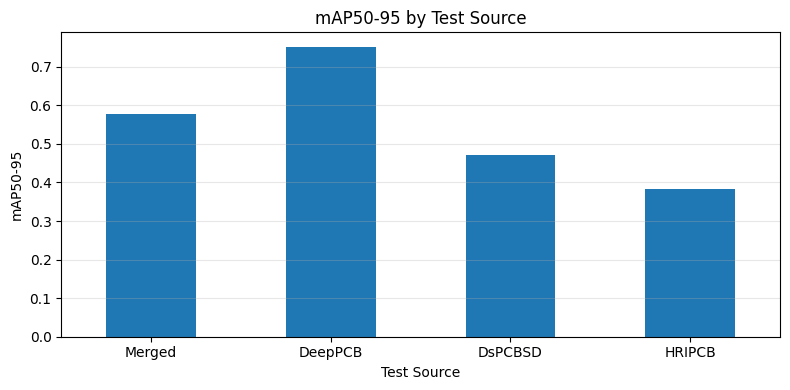

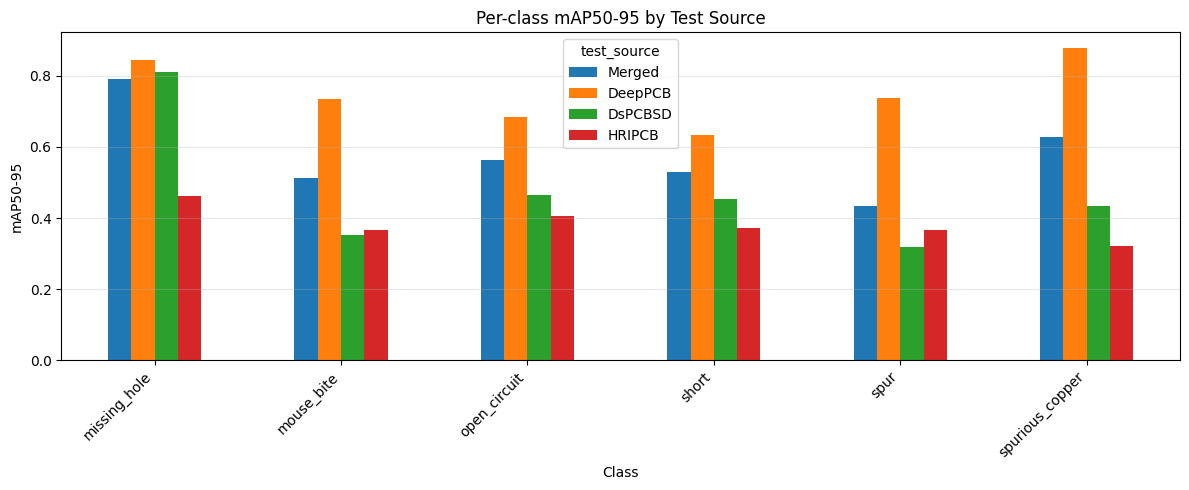

test_source,Merged,DeepPCB,DsPCBSD,HRIPCB
class_name,,,,
missing_hole,0.791187,0.843429,0.809756,0.461973
mouse_bite,0.511901,0.733825,0.352867,0.365793
open_circuit,0.562815,0.683353,0.463549,0.406255
short,0.529209,0.634313,0.452745,0.370804
spur,0.435257,0.736467,0.318376,0.365645
spurious_copper,0.628245,0.878621,0.435085,0.322188


In [14]:
plot_sourcewise_metrics(
    sourcewise_summary_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_map50_95.png",
)

per_class_source_pivot = plot_per_class_sourcewise(
    sourcewise_per_class_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map50_95.png",
)

if per_class_source_pivot is not None:
    display(per_class_source_pivot)
    per_class_source_pivot.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_pivot.csv")

## 14. Show training artifacts

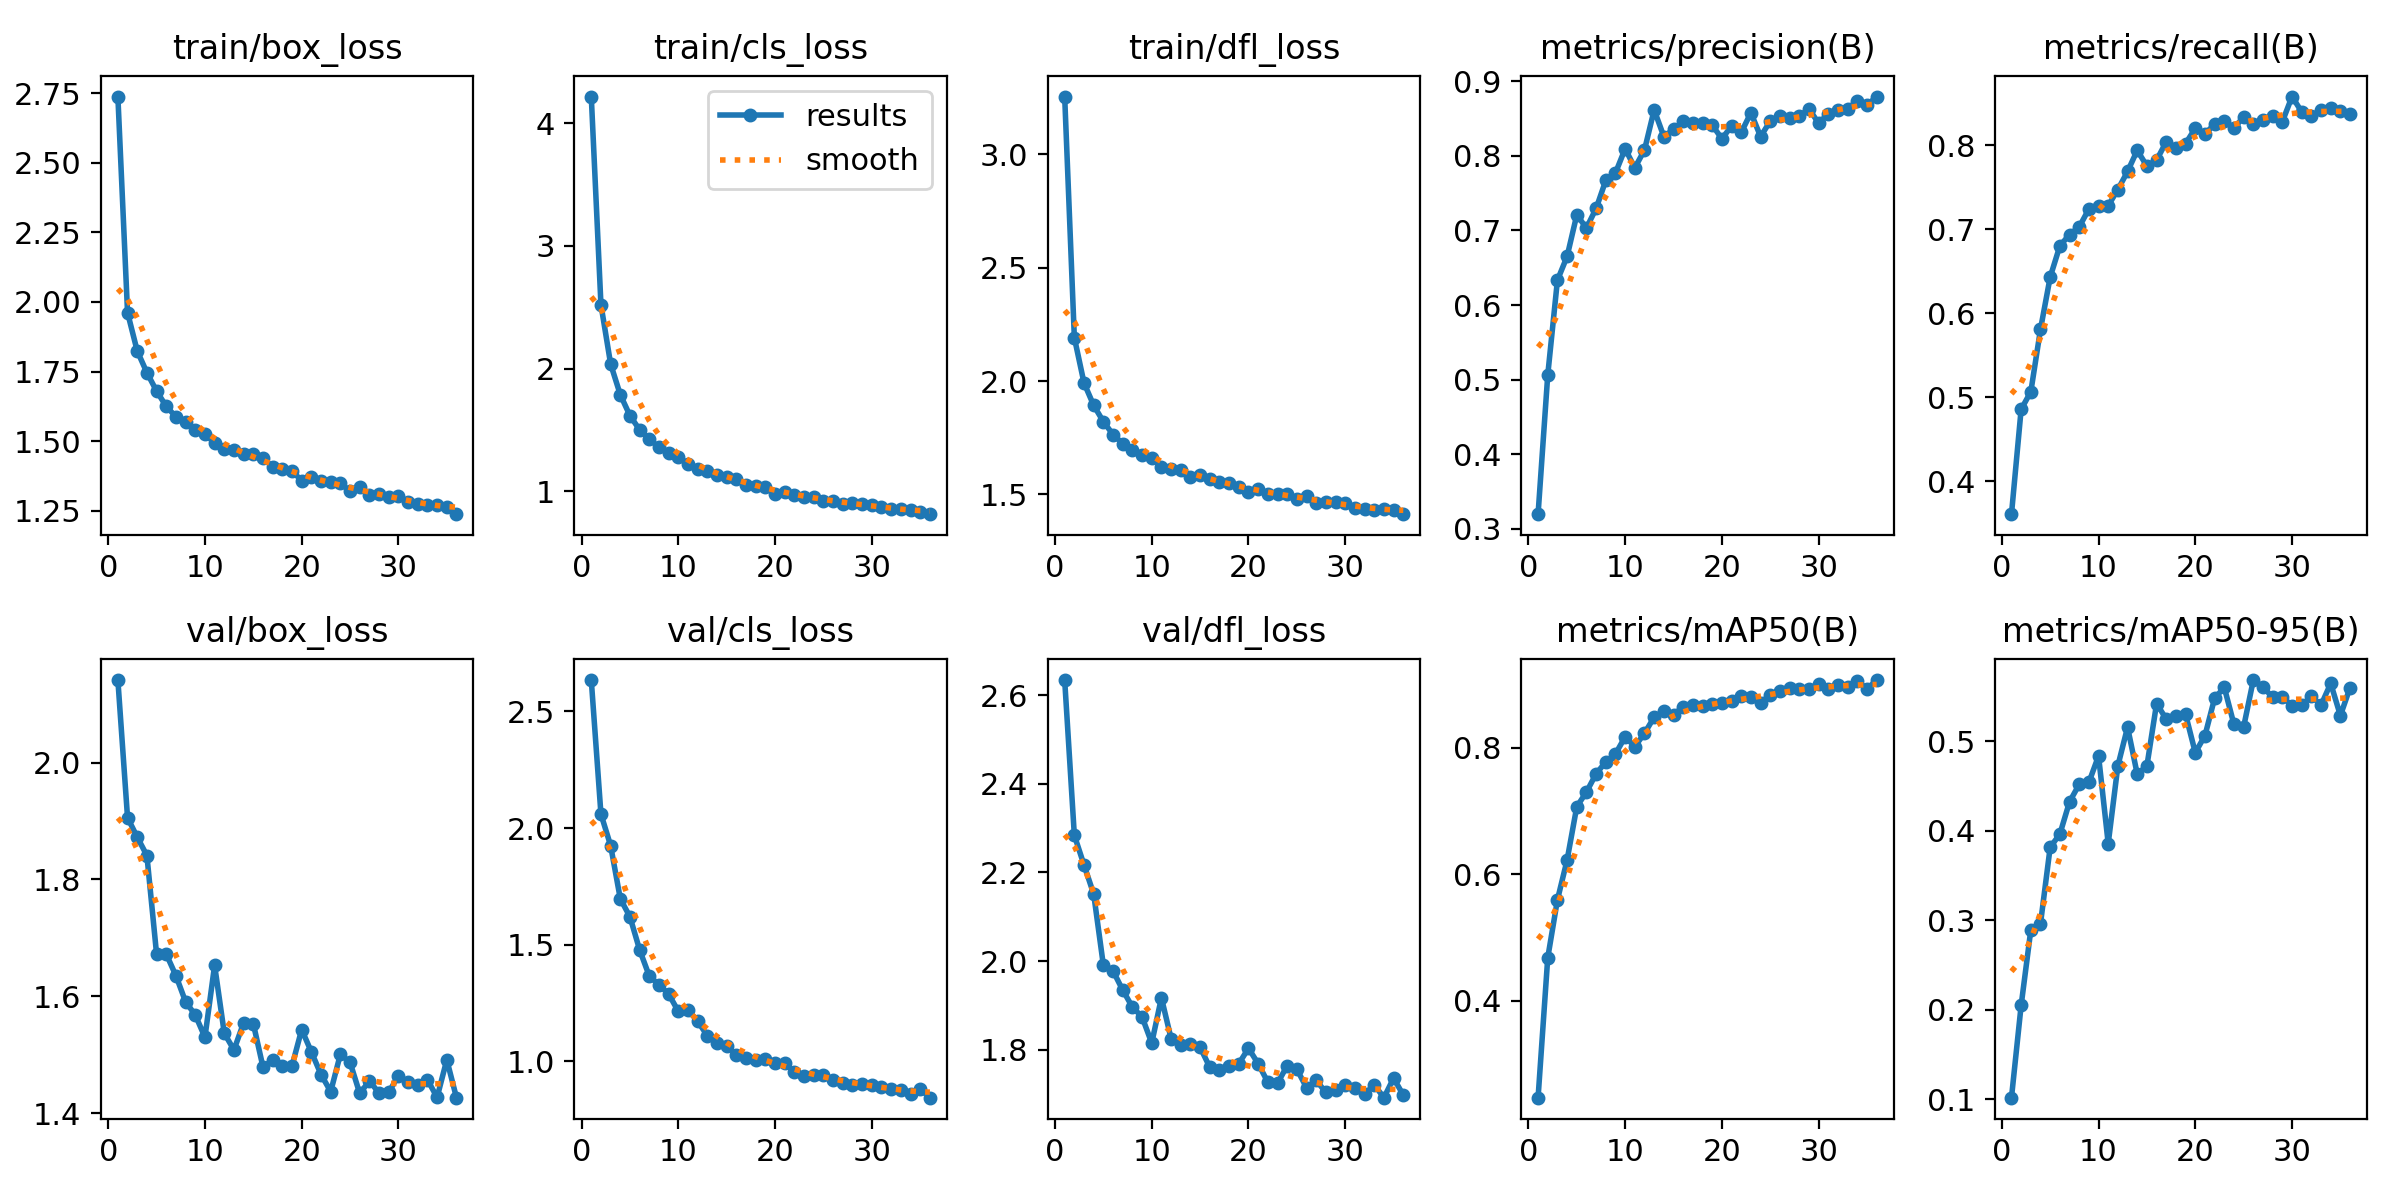

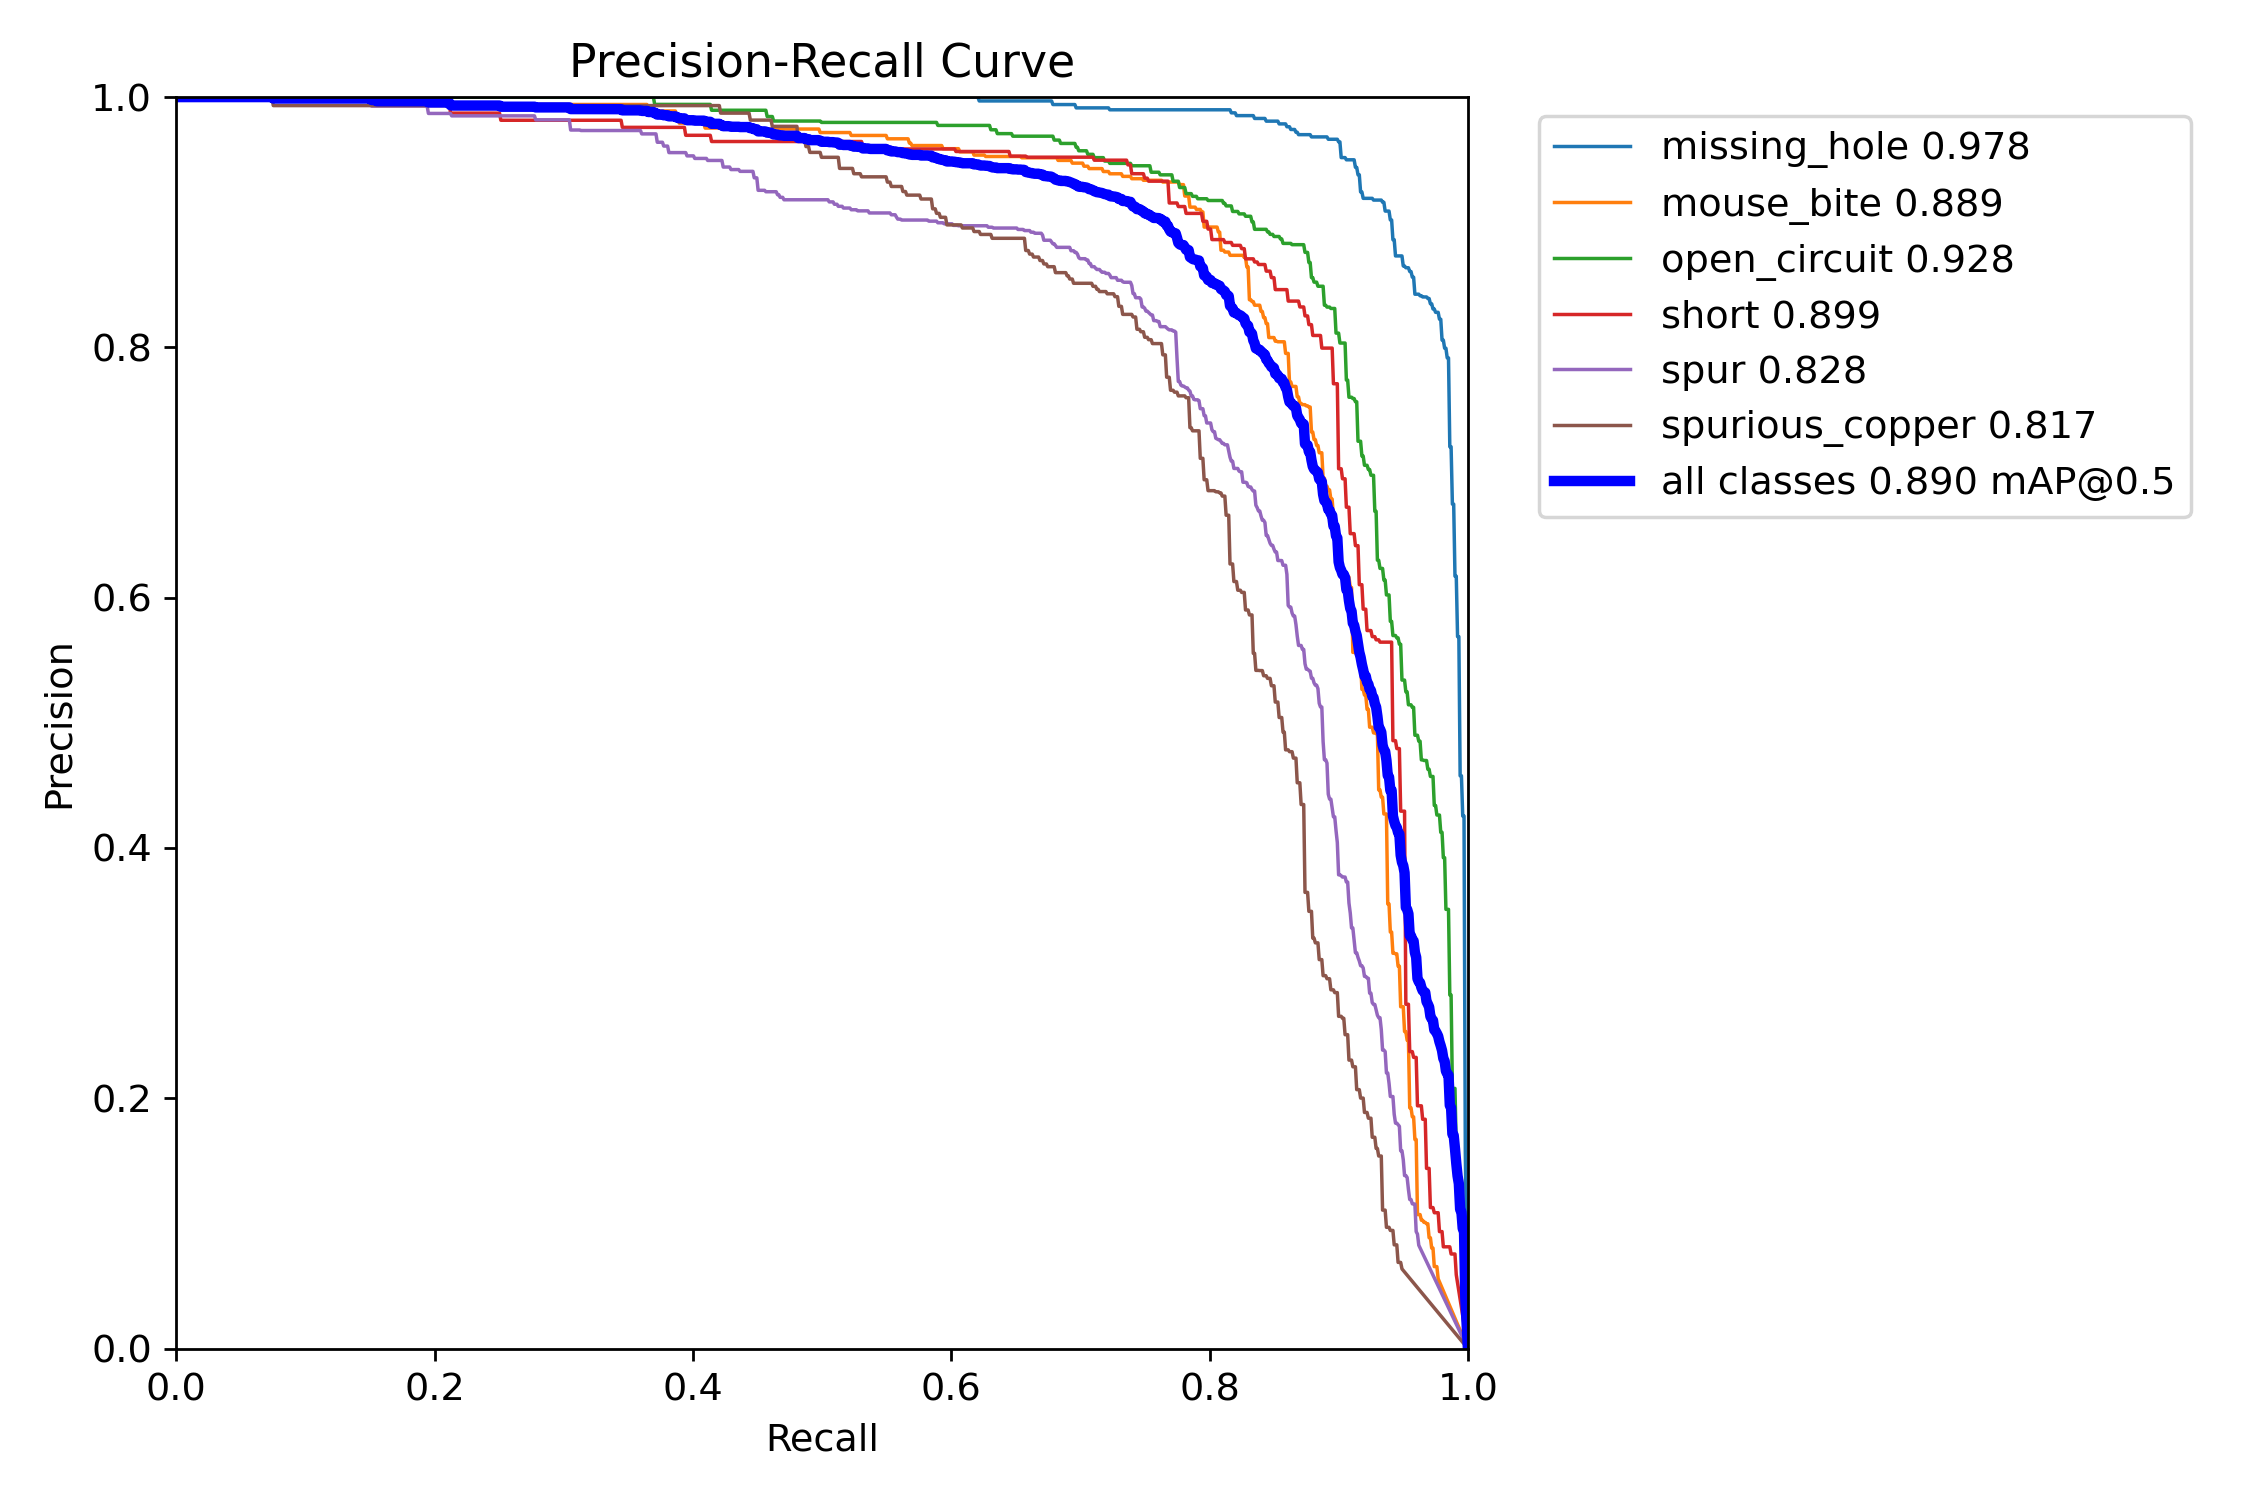

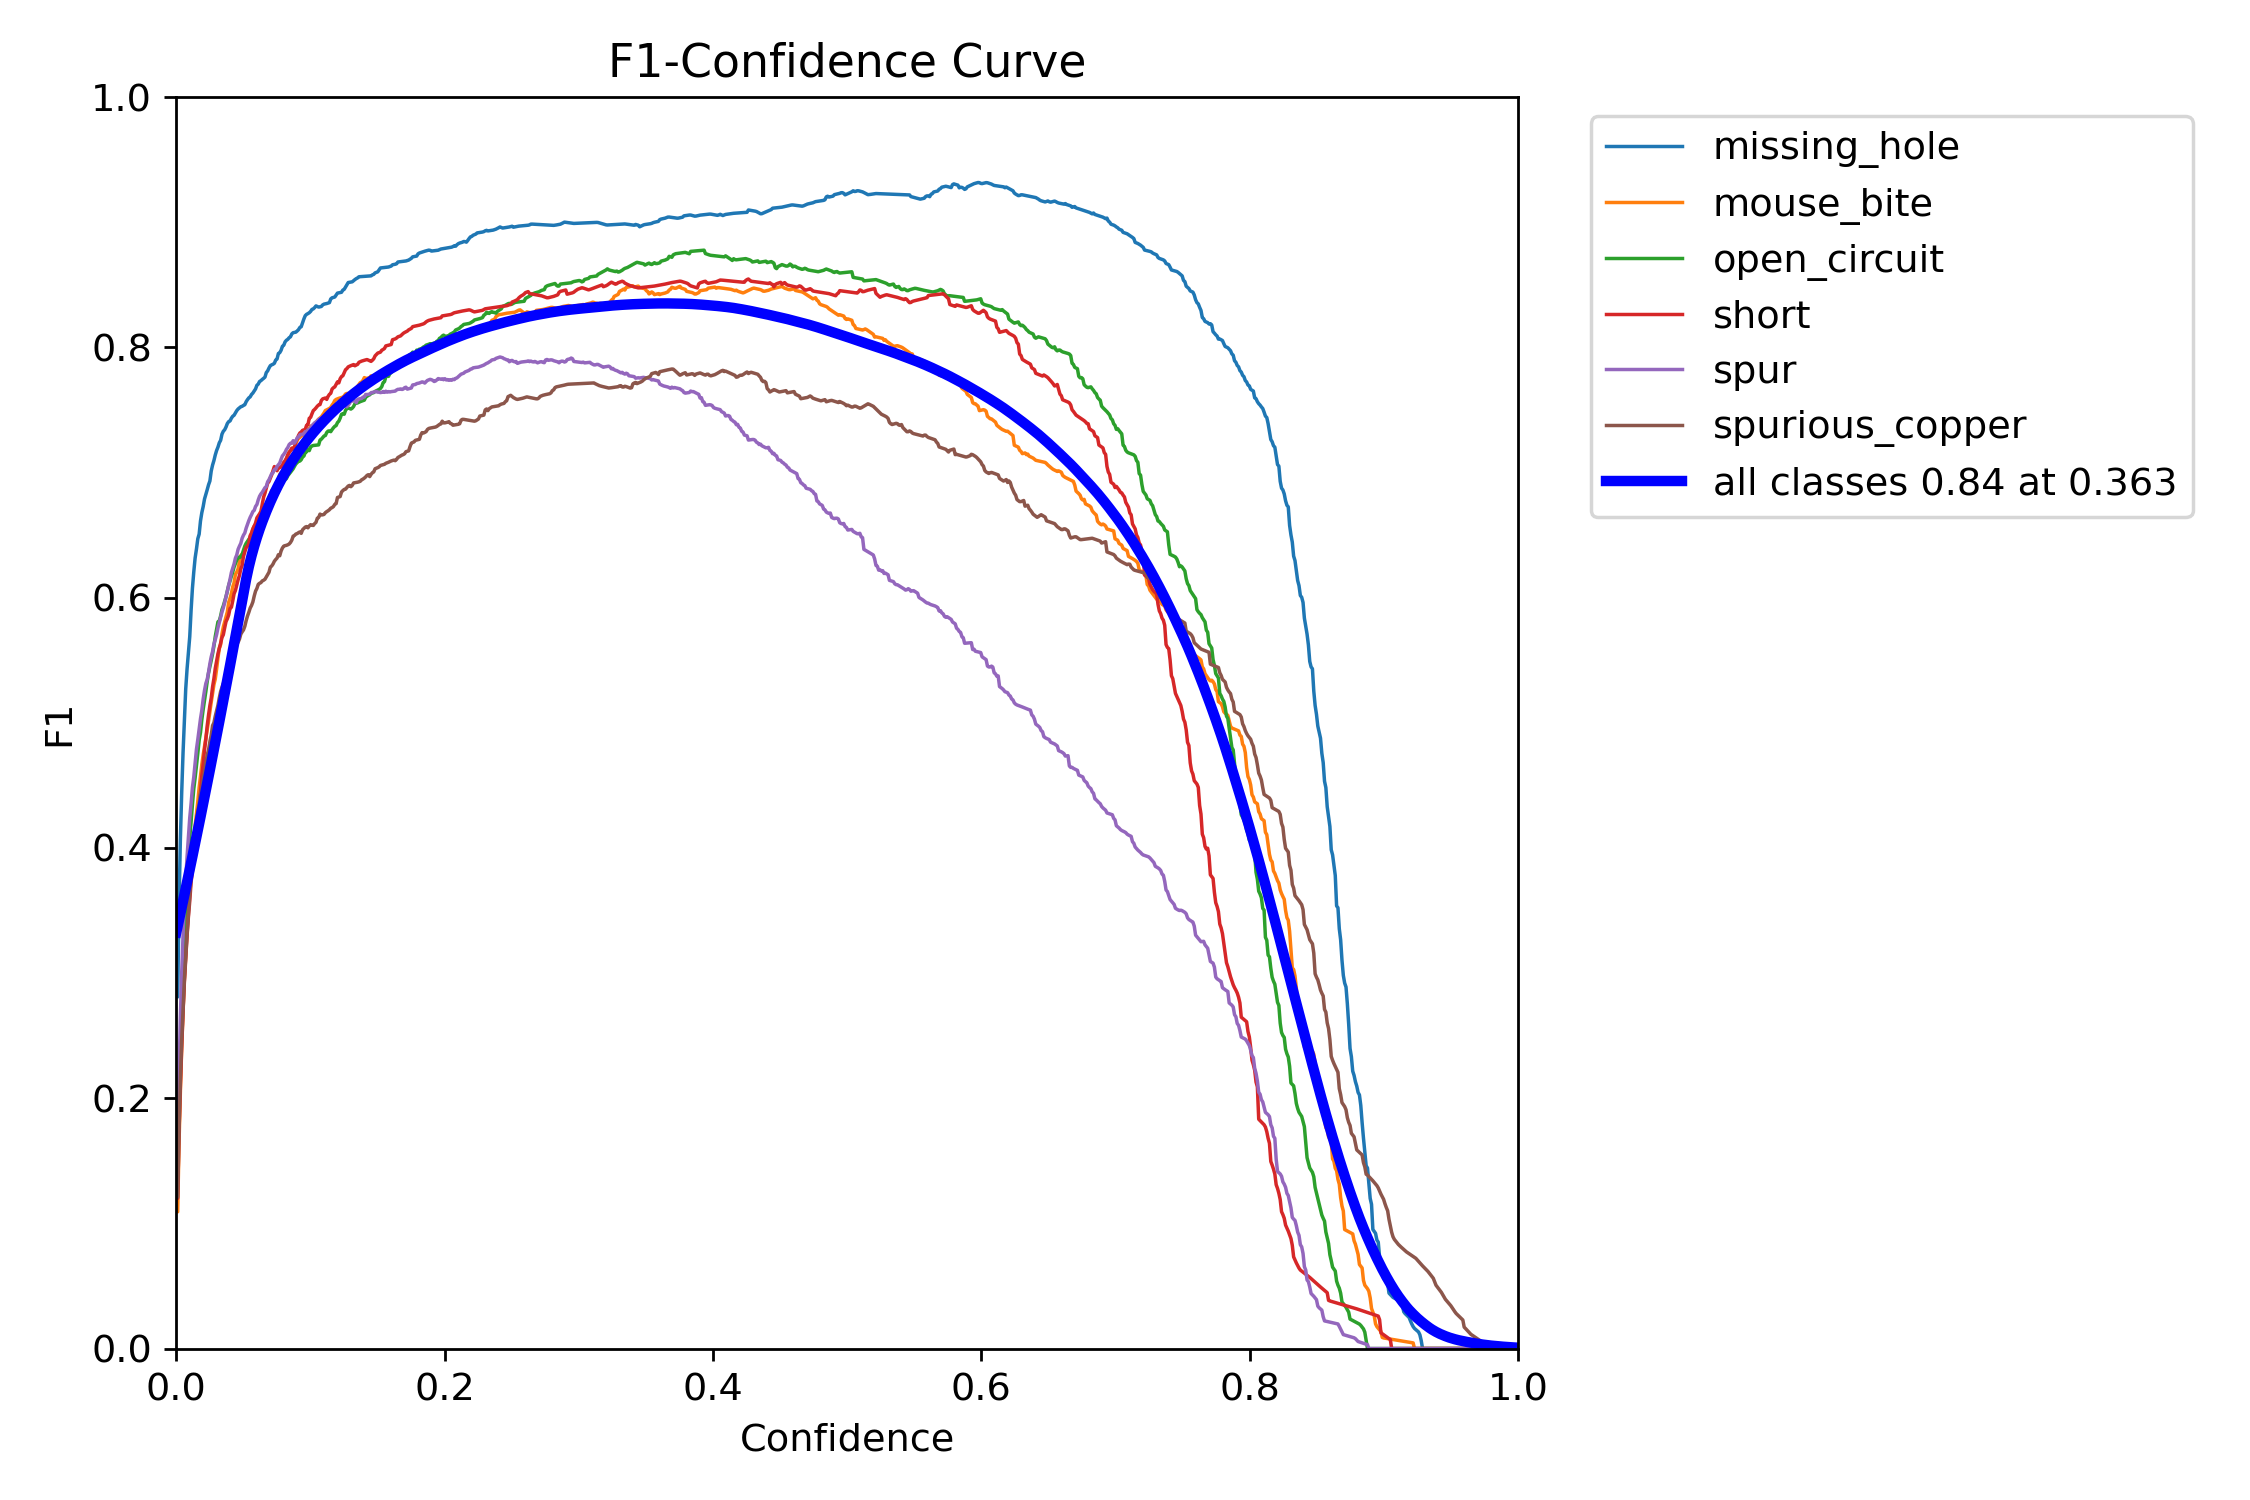

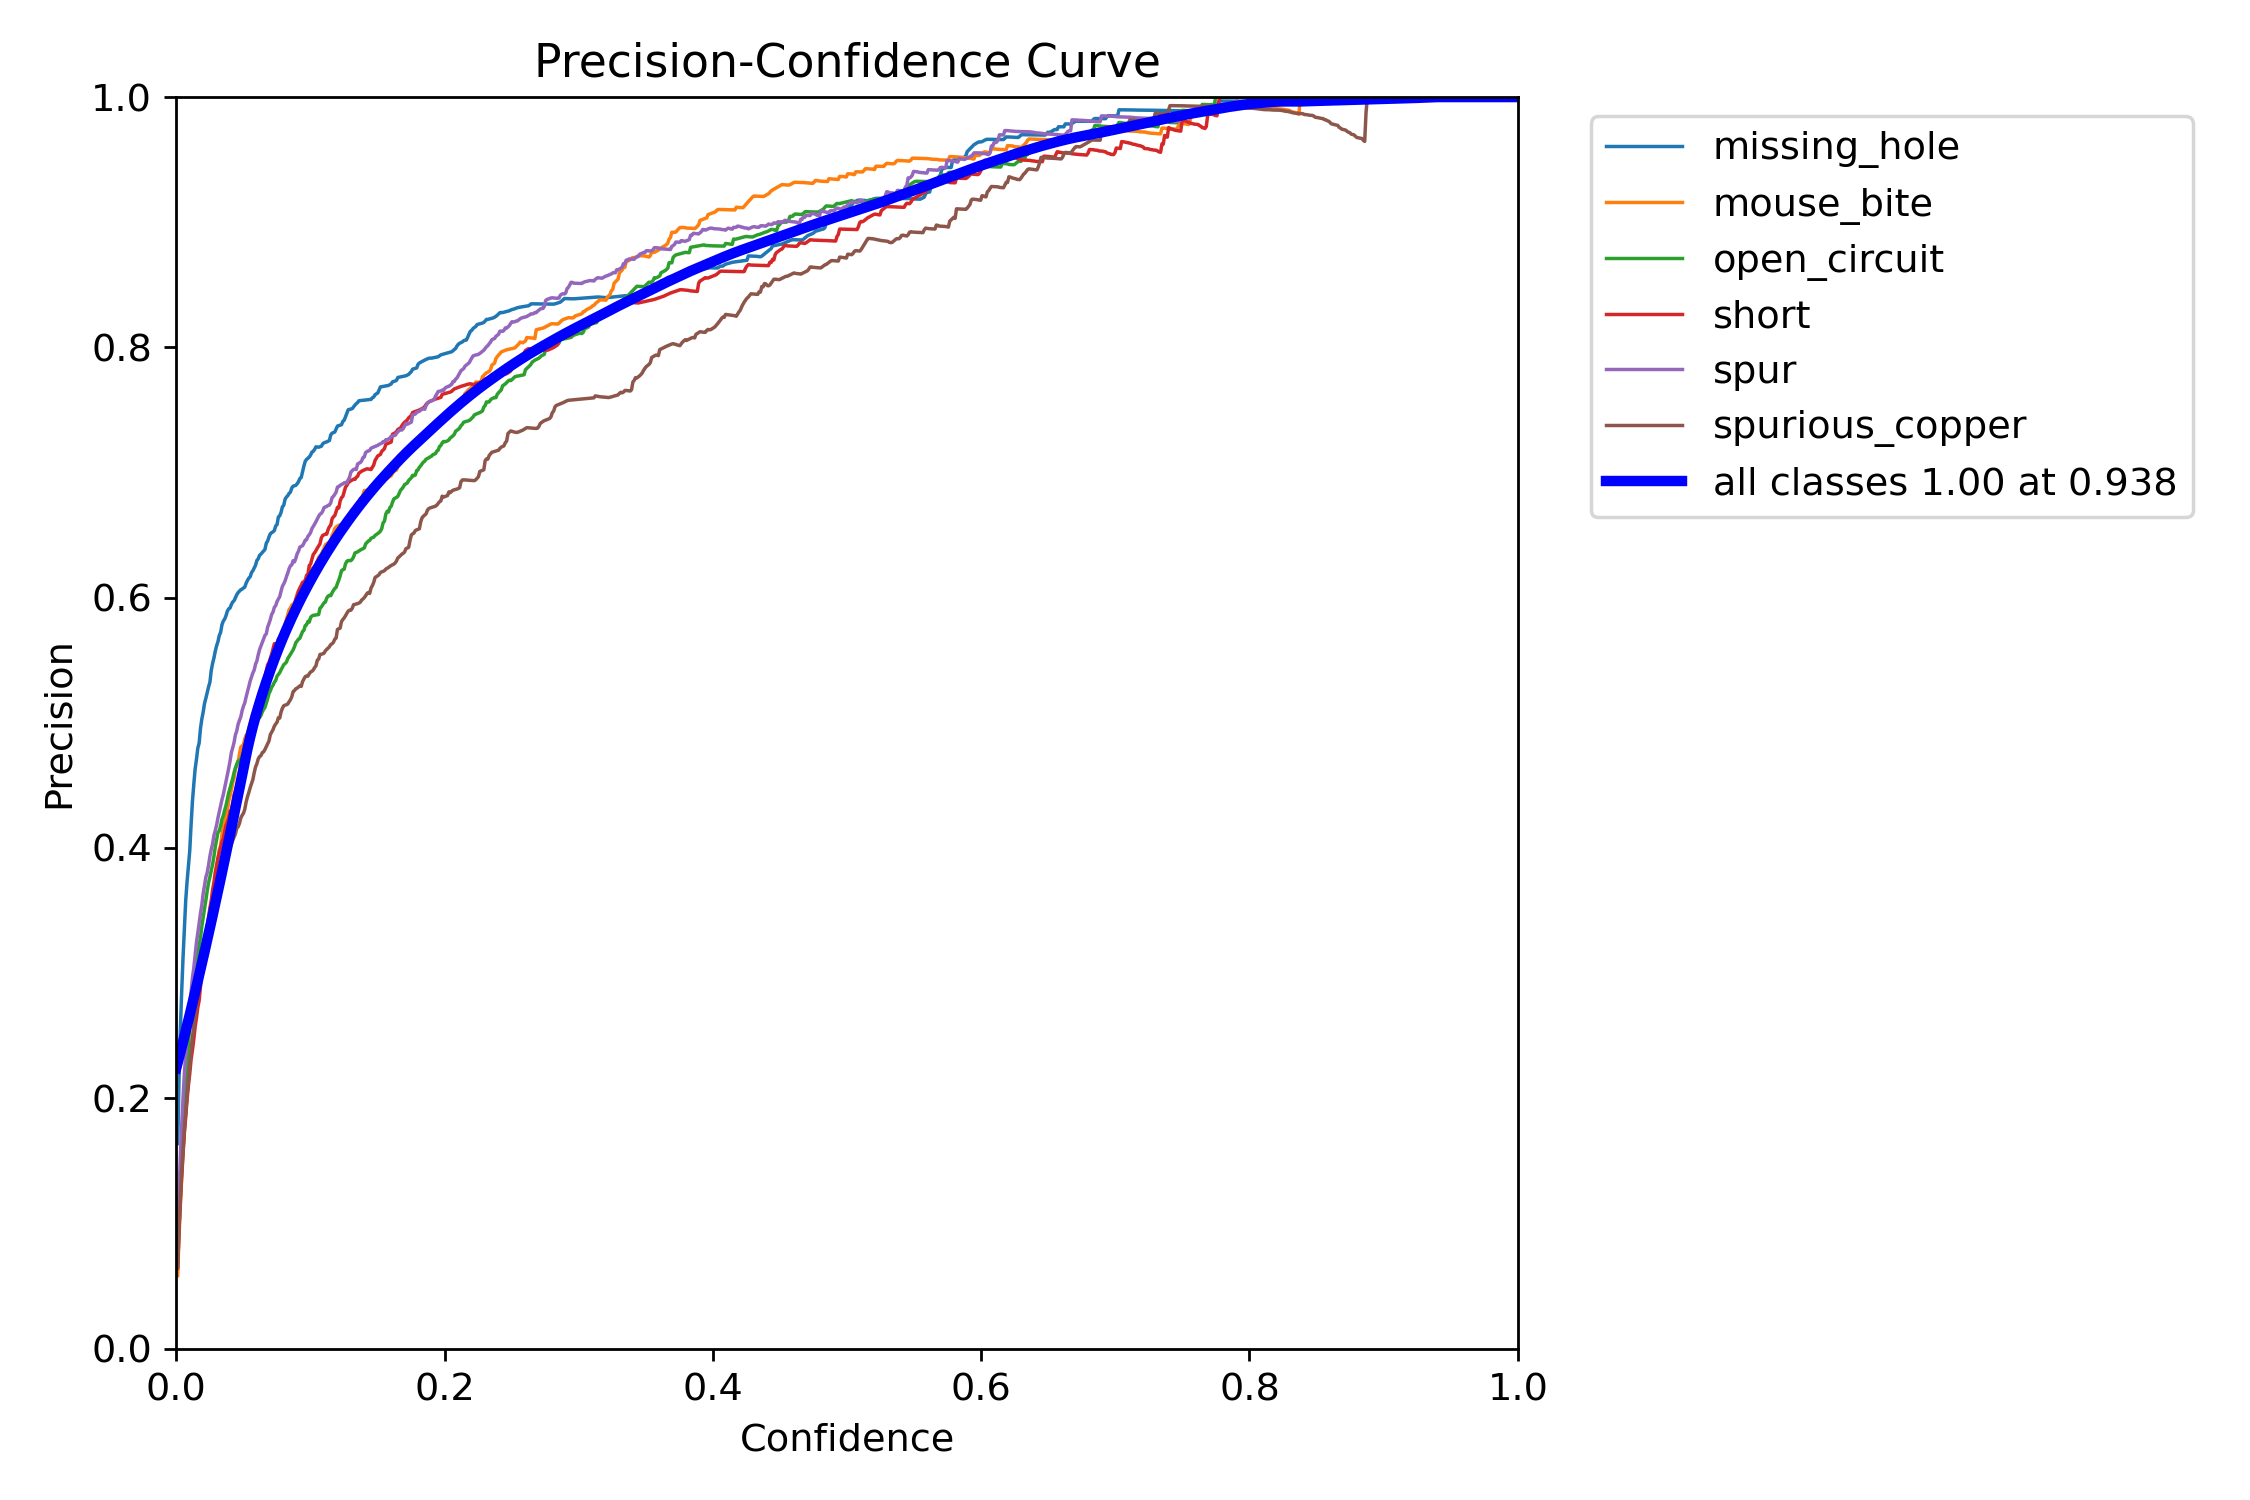

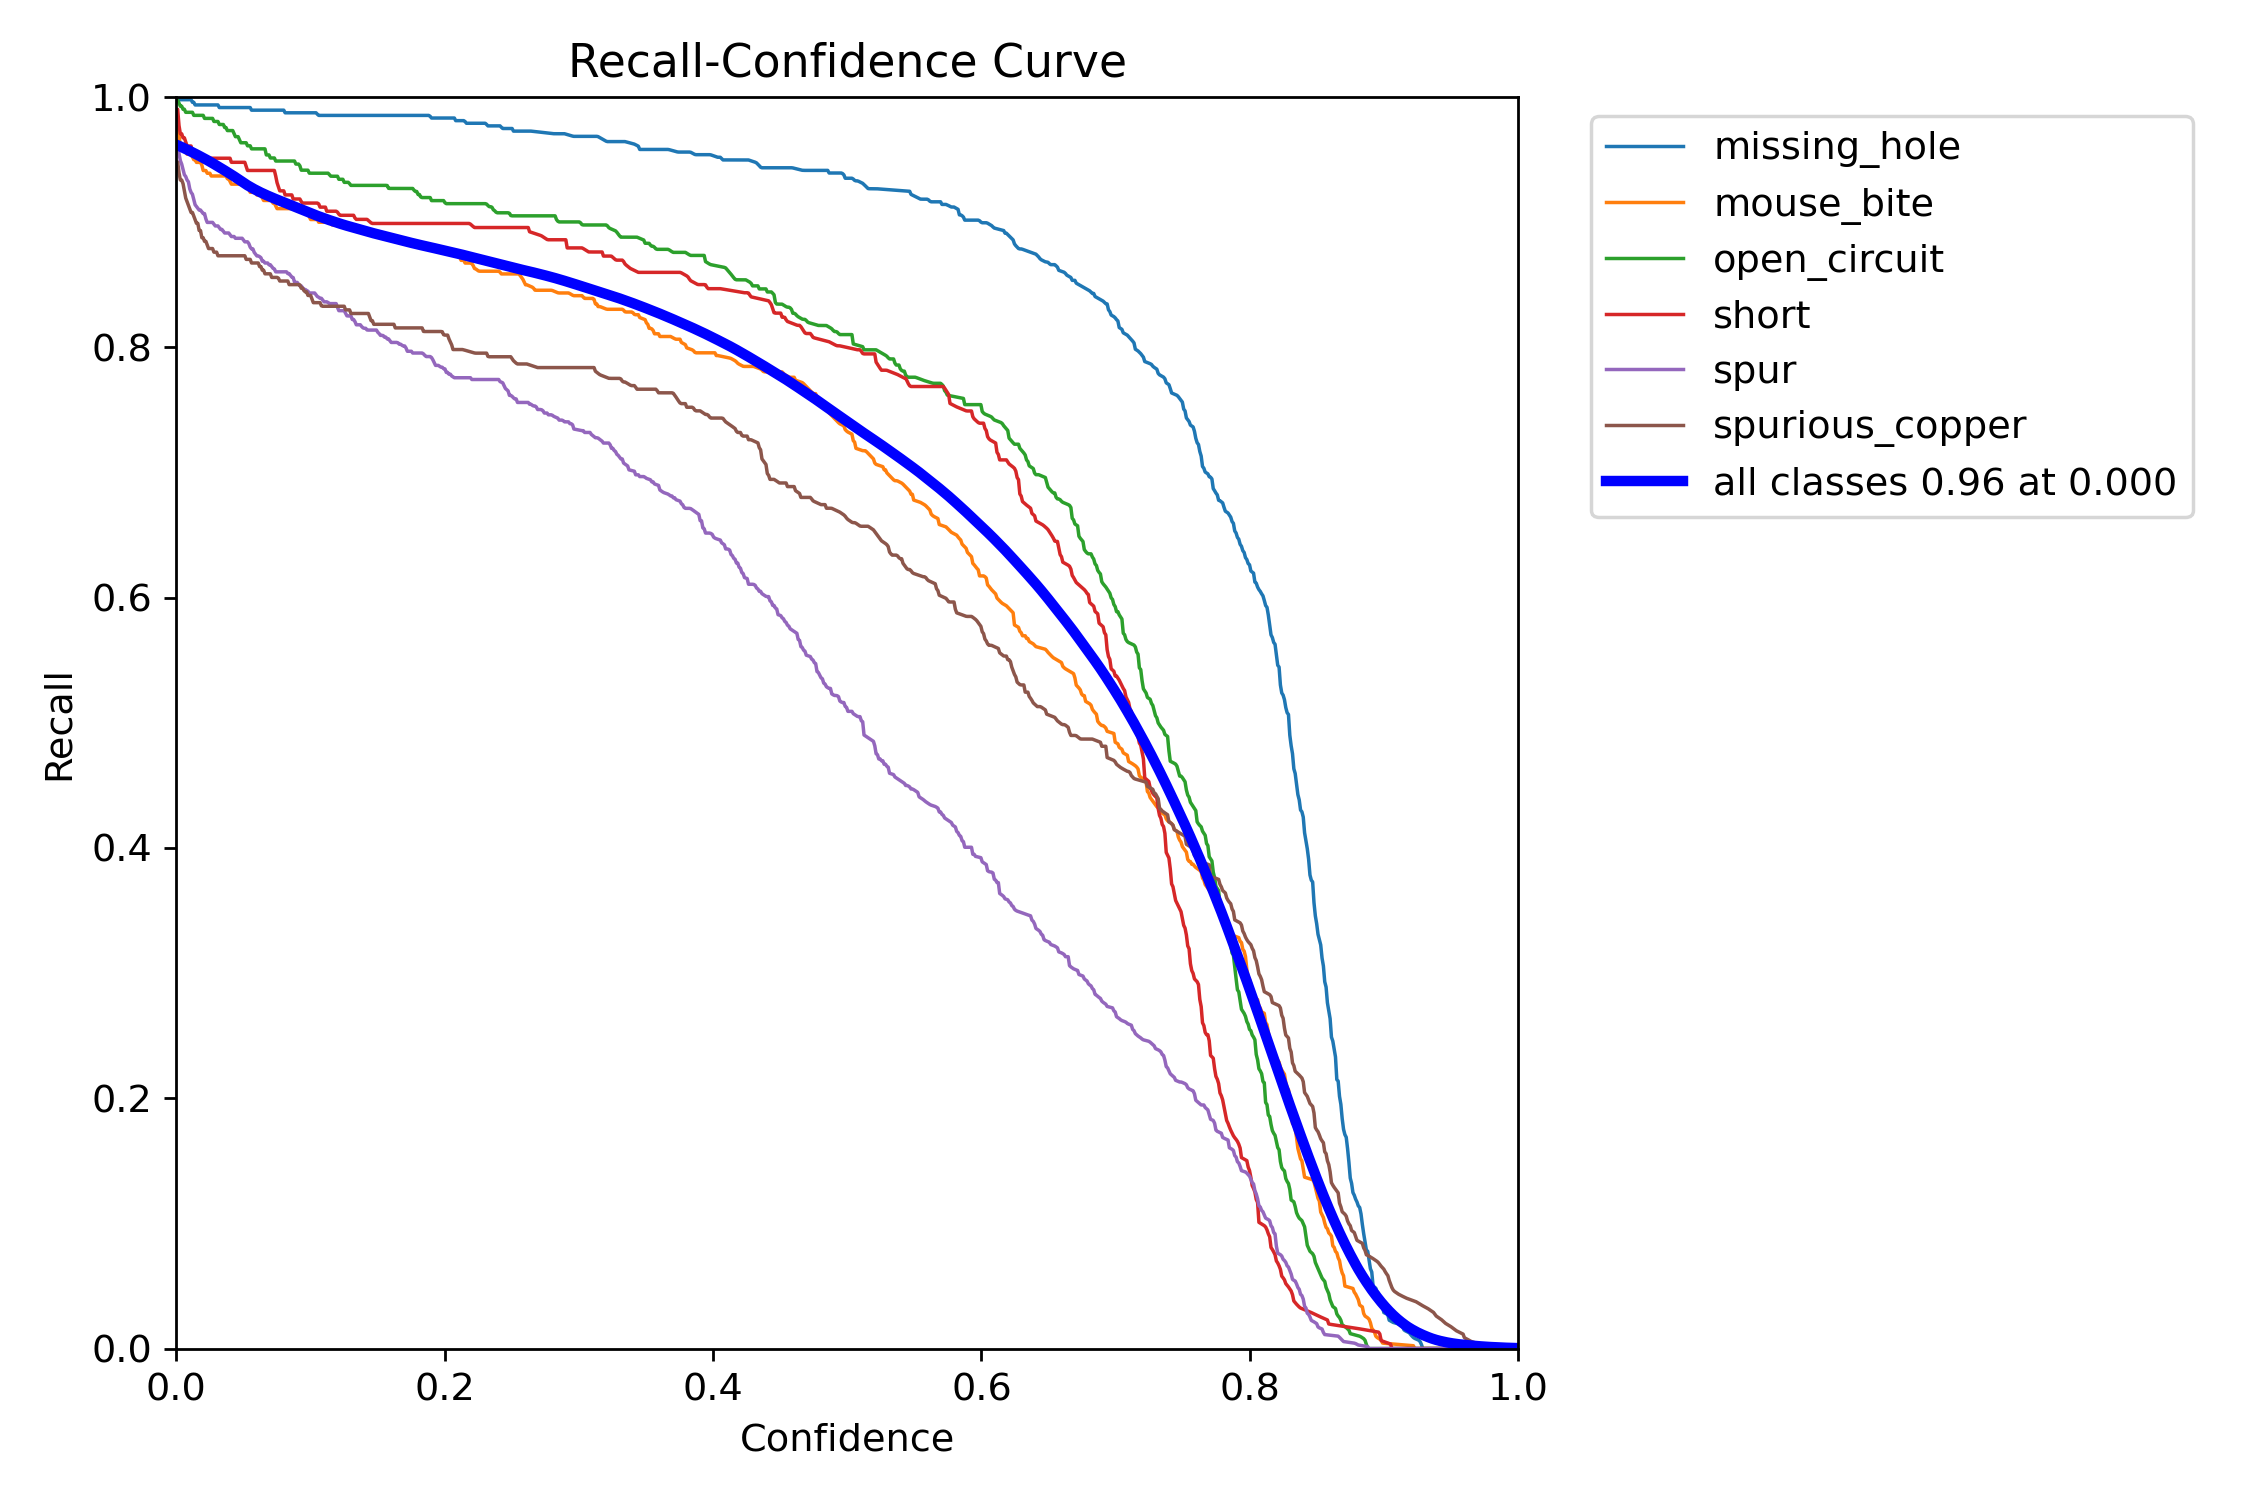

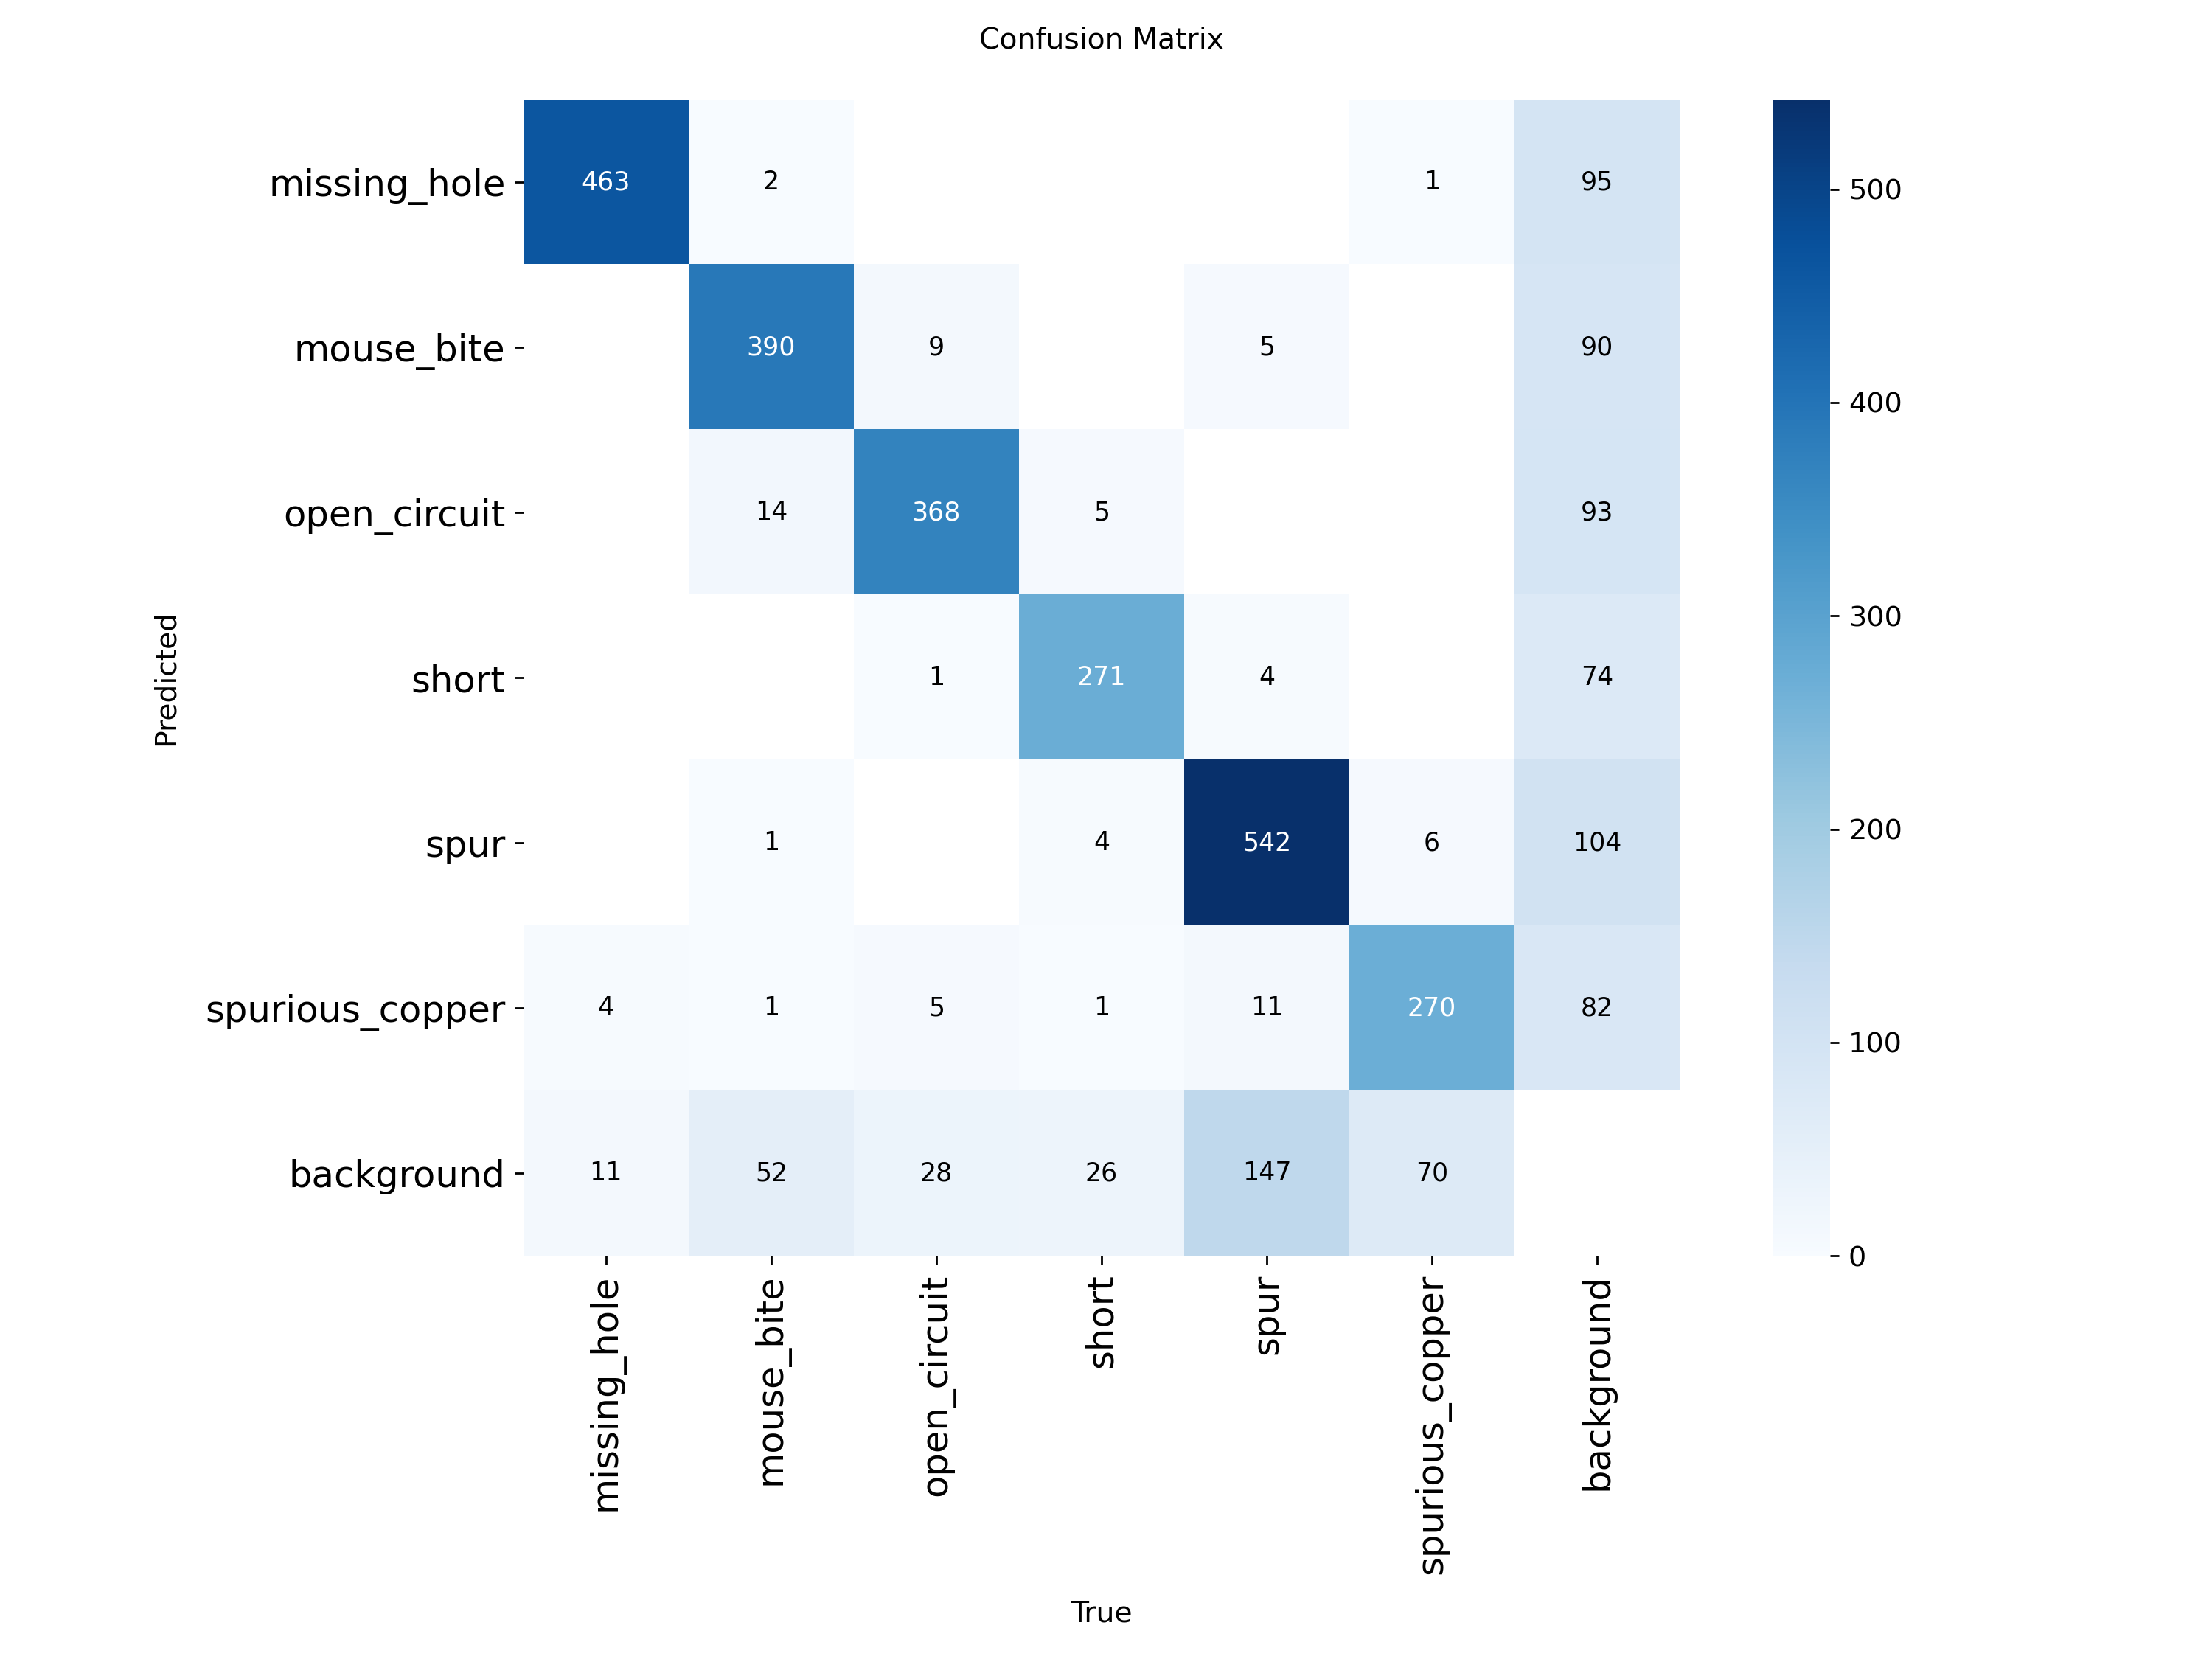

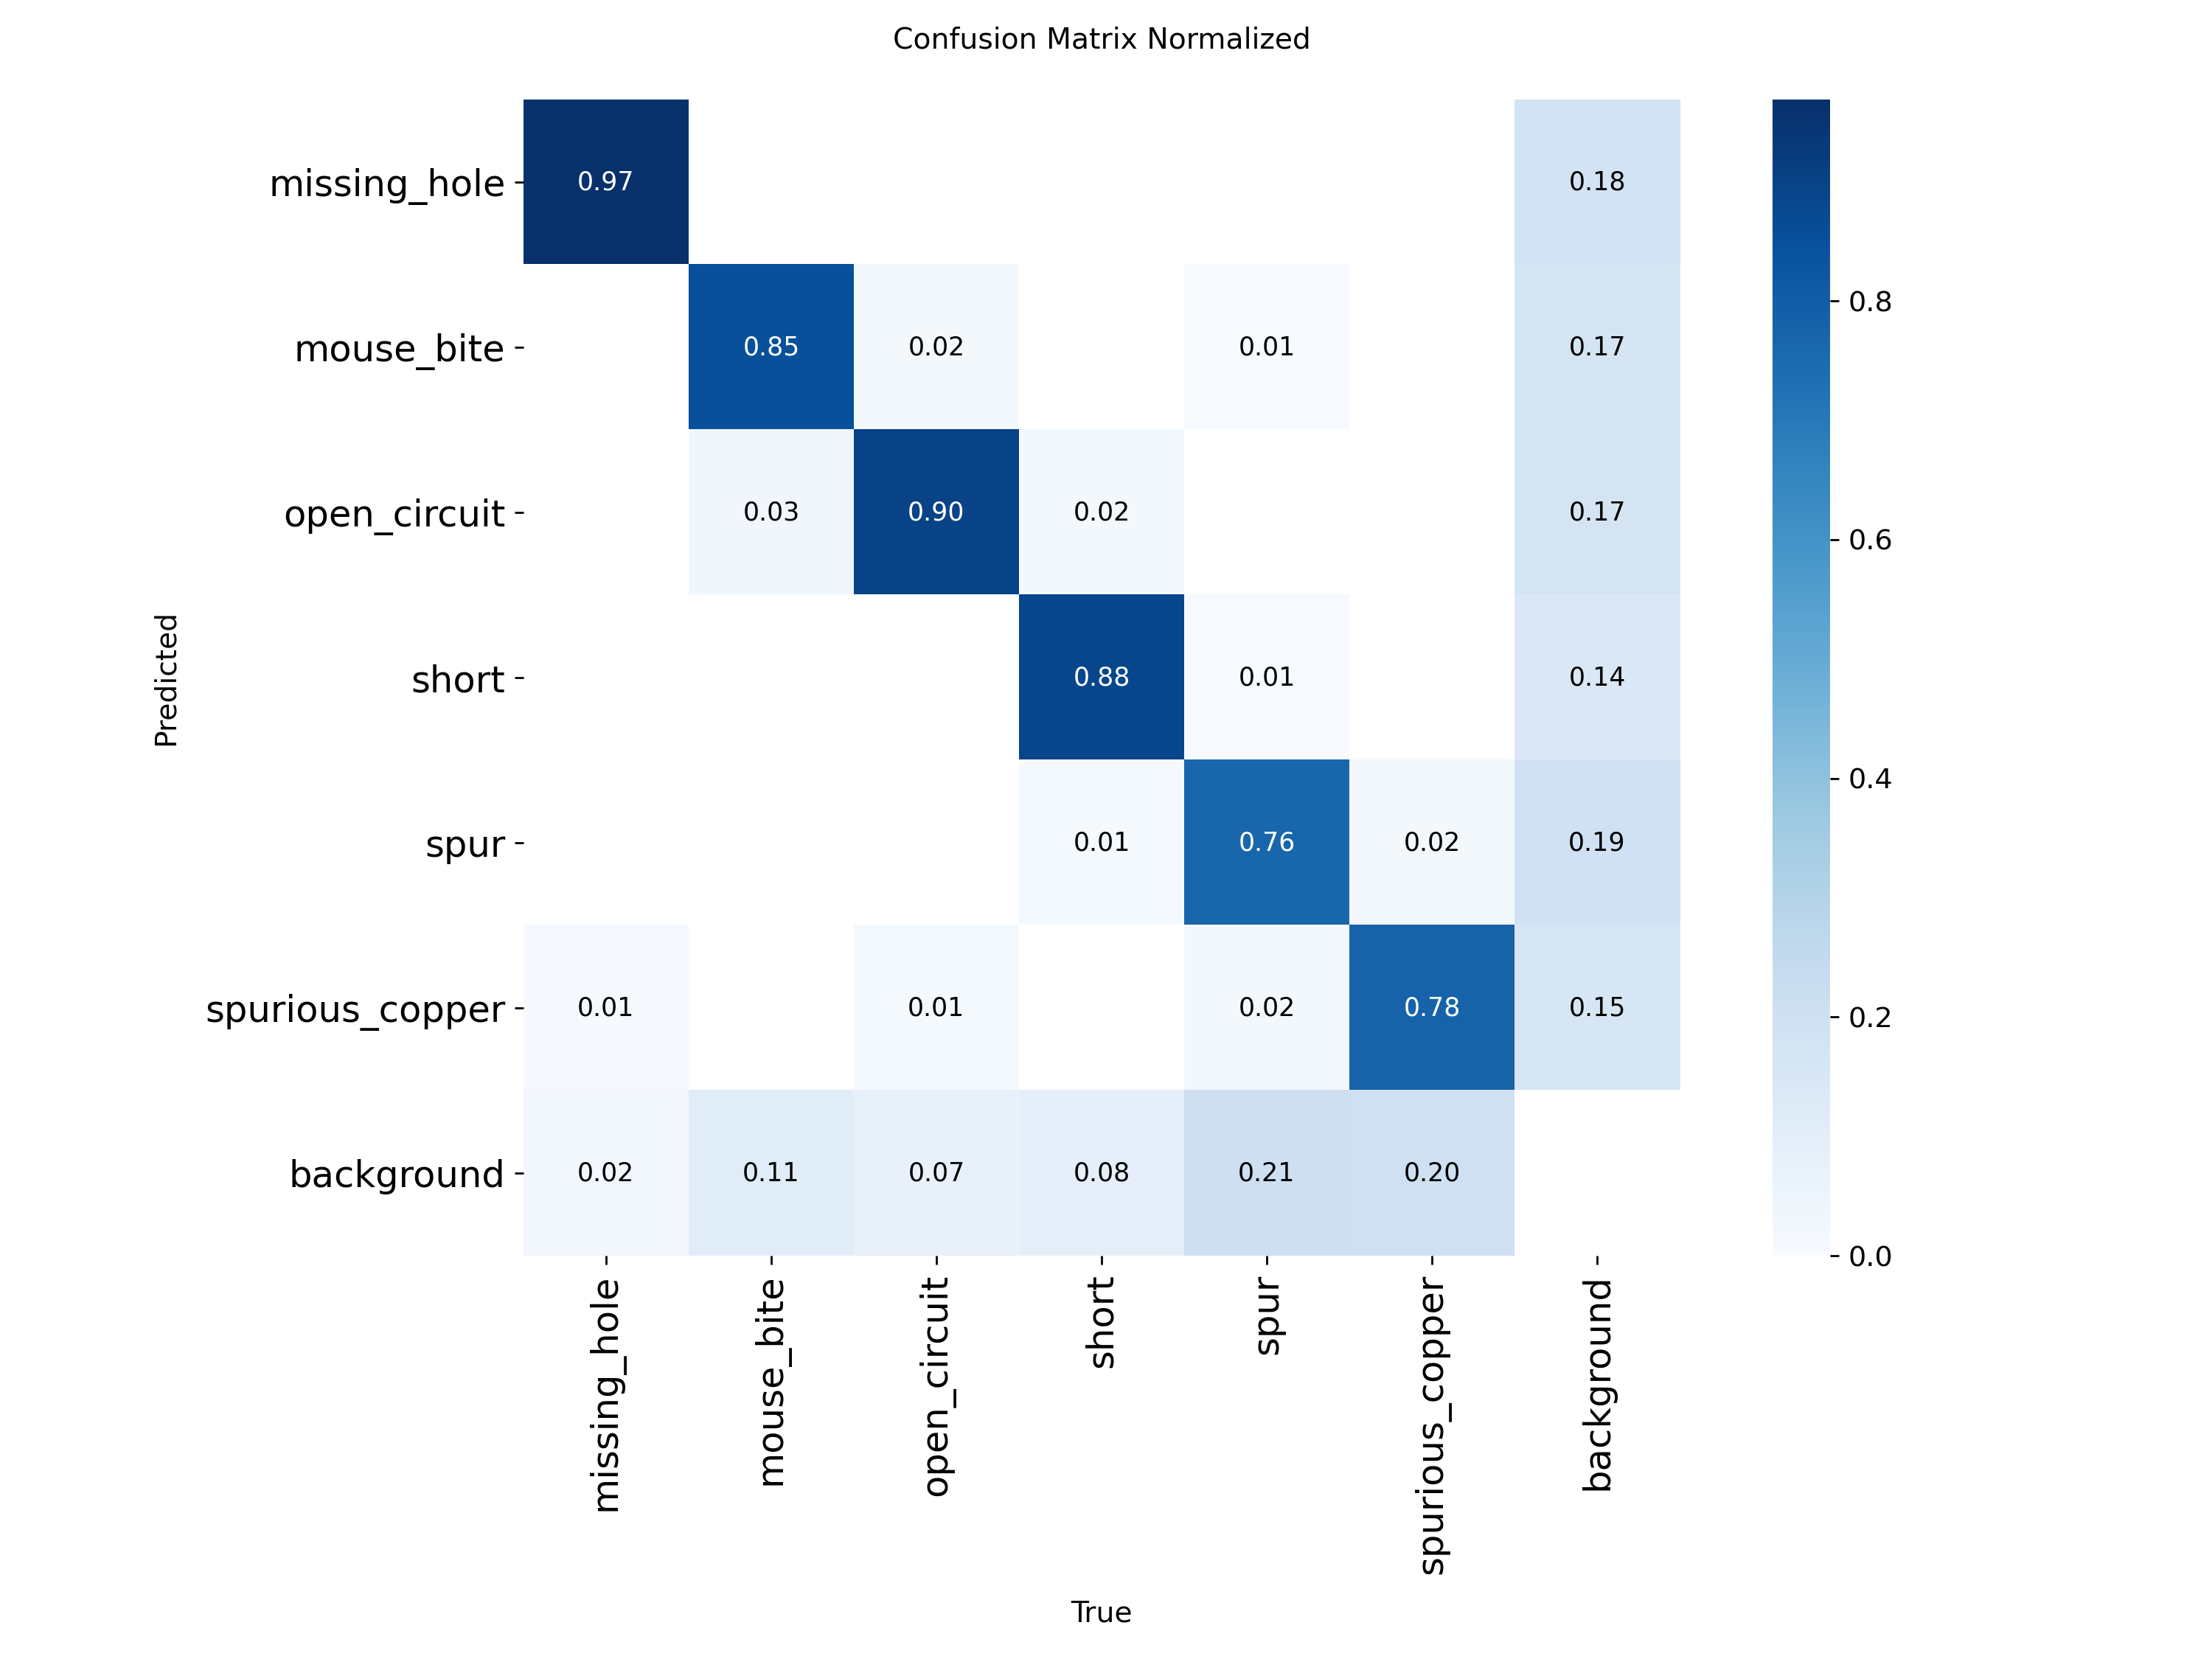

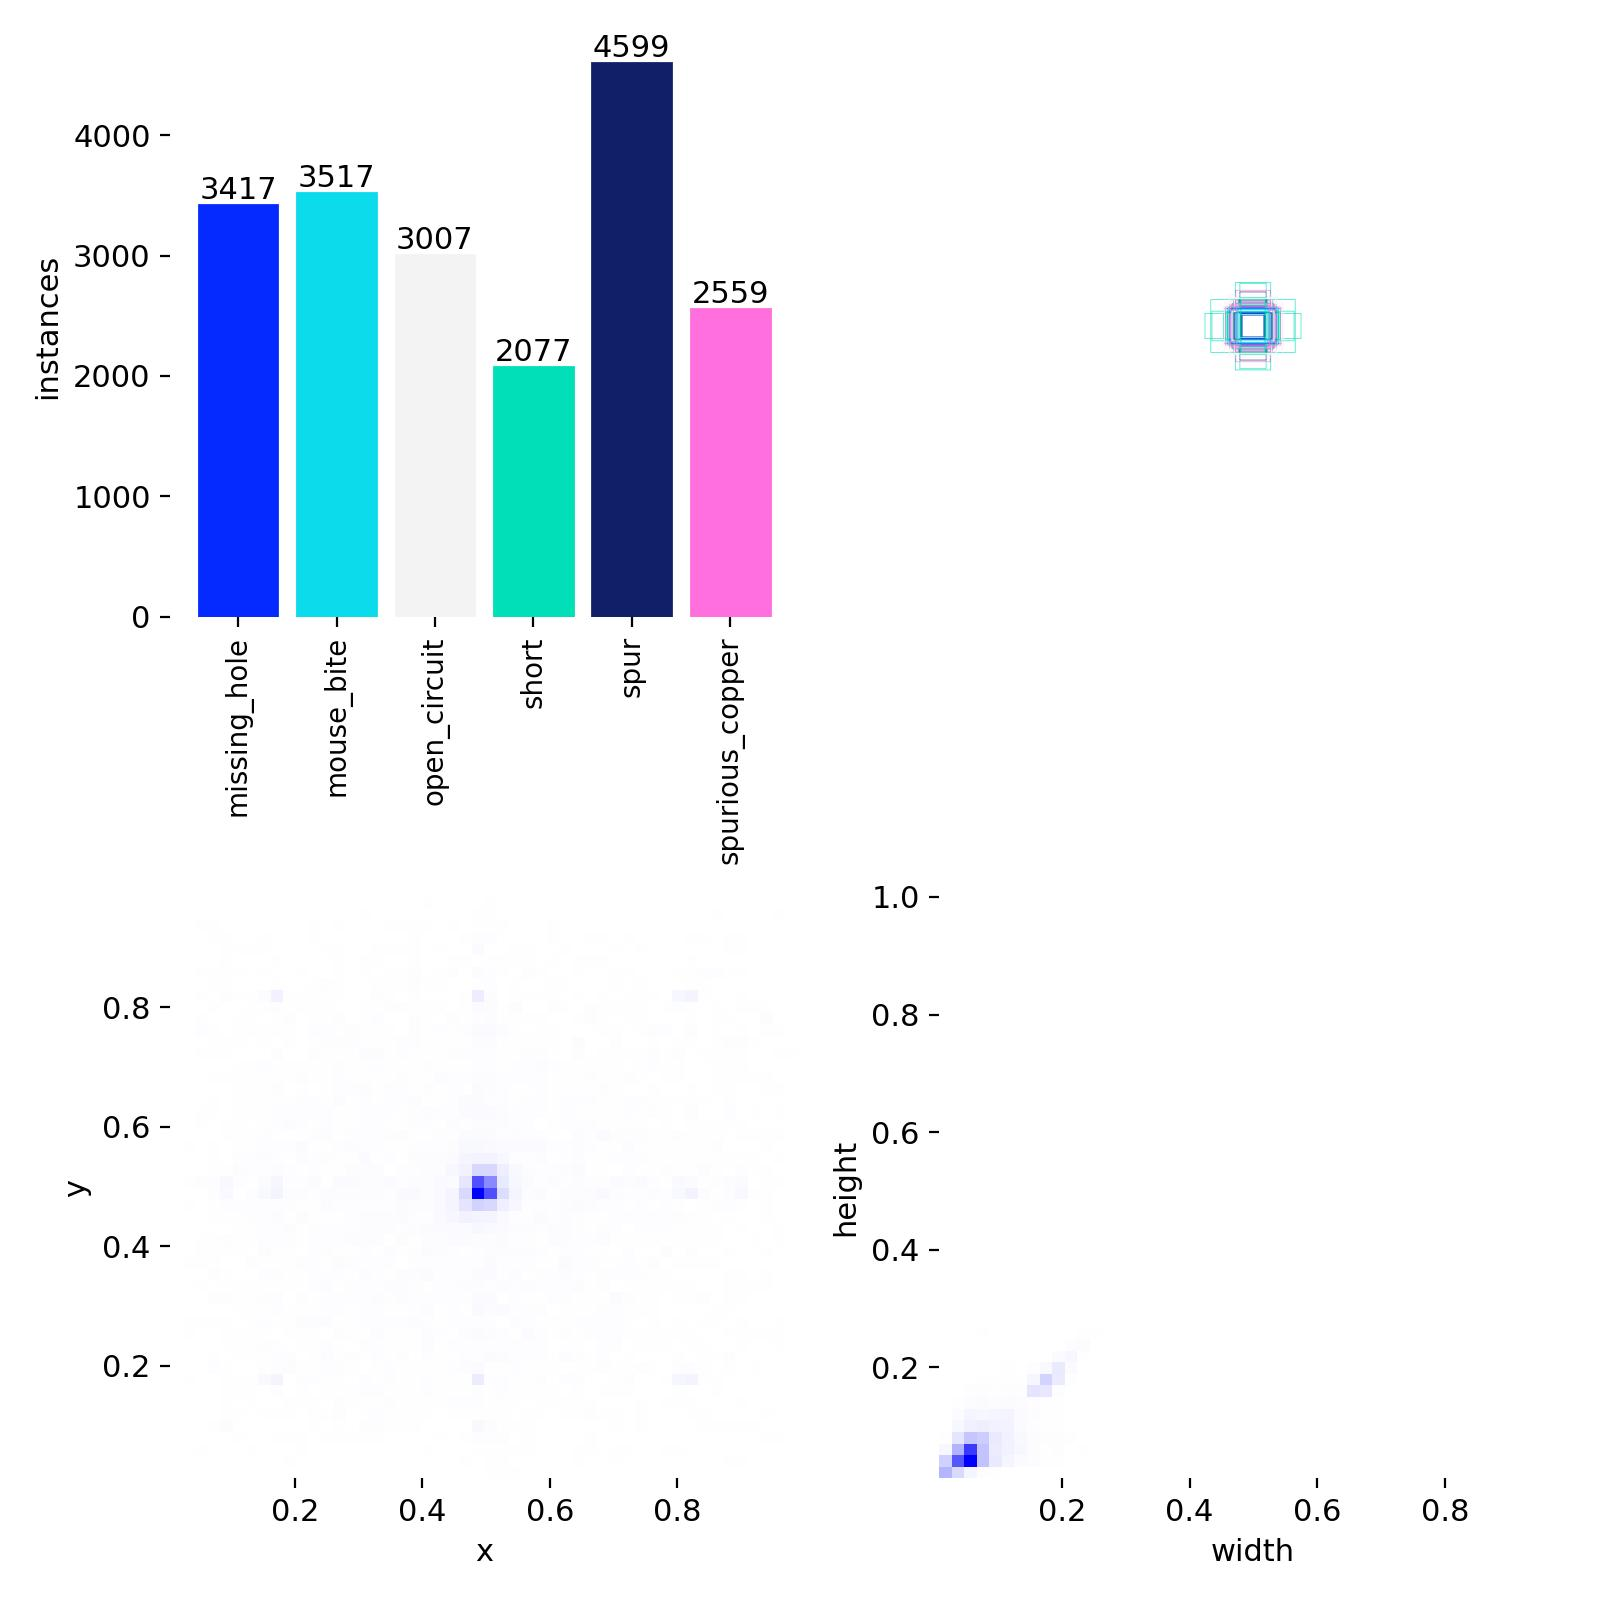

In [15]:
train_artifacts = [
    TRAIN_DIR / "results.png",
    TRAIN_DIR / "BoxPR_curve.png",
    TRAIN_DIR / "BoxF1_curve.png",
    TRAIN_DIR / "BoxP_curve.png",
    TRAIN_DIR / "BoxR_curve.png",
    TRAIN_DIR / "confusion_matrix.png",
    TRAIN_DIR / "confusion_matrix_normalized.png",
    TRAIN_DIR / "labels.jpg",
]

for p in train_artifacts:
    show_image(p)

## 15. Plot training curves

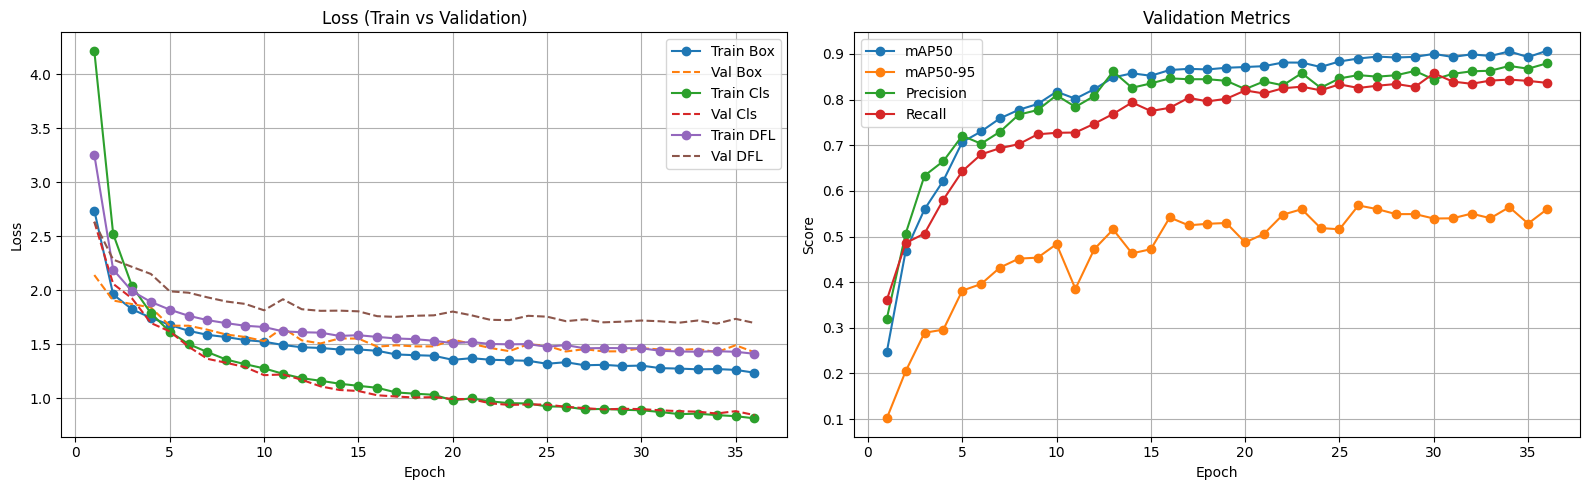

In [16]:
plot_results_csv(
    RESULTS_CSV,
    loss_cols=[
        ("train/box_loss", "Train Box", "-"),
        ("val/box_loss", "Val Box", "--"),
        ("train/cls_loss", "Train Cls", "-"),
        ("val/cls_loss", "Val Cls", "--"),
        ("train/dfl_loss", "Train DFL", "-"),
        ("val/dfl_loss", "Val DFL", "--"),
    ],
)

## 16. Predict sample test images


0: 640x640 3 missing_holes, 15.3ms
1: 640x640 5 missing_holes, 15.3ms
2: 640x640 2 missing_holes, 15.3ms
3: 640x640 1 spur, 15.3ms
4: 640x640 1 spurious_copper, 15.3ms
5: 640x640 1 mouse_bite, 15.3ms
6: 640x640 1 spurious_copper, 15.3ms
7: 640x640 1 open_circuit, 2 spurious_coppers, 15.3ms
8: 640x640 3 spurs, 15.3ms
9: 640x640 1 spur, 15.3ms
10: 640x640 1 missing_hole, 1 mouse_bite, 1 spurious_copper, 15.3ms
11: 640x640 1 missing_hole, 1 mouse_bite, 3 open_circuits, 1 short, 1 spur, 1 spurious_copper, 15.3ms
12: 640x640 2 missing_holes, 1 open_circuit, 1 short, 1 spur, 1 spurious_copper, 15.3ms
13: 640x640 1 mouse_bite, 15.3ms
14: 640x640 2 missing_holes, 1 mouse_bite, 1 open_circuit, 2 spurs, 15.3ms
Speed: 1.6ms preprocess, 15.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/PCB_Baseline/yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_predictions


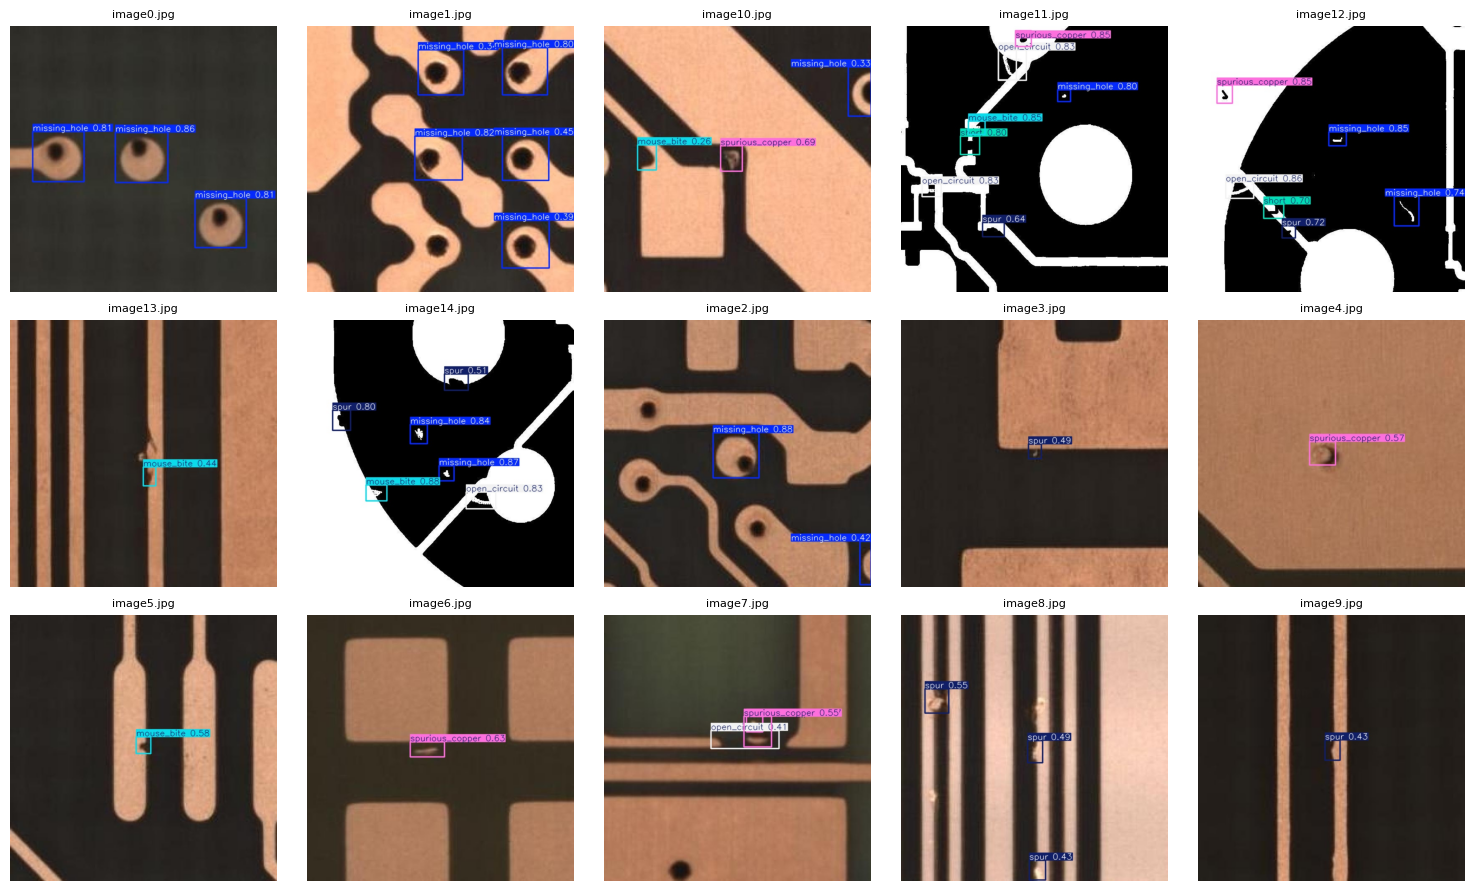

In [17]:
predict_sample_images(
    best_model=best_model,
    data_dir=DATA_DIR,
    project=PROJECT,
    pred_name=PRED_NAME,
    max_images=15,
)

display_prediction_grid(PRED_DIR, n=15)

## 17. Export artifacts

In [18]:
EXPORT_DIR = ARTIFACT_DIR / TRAIN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copy train artifacts.
for file_name in [
    "results.csv",
    "results.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
]:
    src = TRAIN_DIR / file_name
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / file_name)

# Copy best/last weight.
if EVAL_PT.exists():
    shutil.copy2(EVAL_PT, EXPORT_DIR / EVAL_PT.name)

# Copy custom model YAML.
if CUSTOM_MODEL_YAML.exists():
    shutil.copy2(CUSTOM_MODEL_YAML, EXPORT_DIR / CUSTOM_MODEL_YAML.name)

# Copy report CSV/PNG/JSON.
for p in REPORT_DIR.glob(f"{TRAIN_NAME}*"):
    shutil.copy2(p, EXPORT_DIR / p.name)

# Copy dataset/source summaries.
for p in [
    REPORT_DIR / "dataset_summary.csv",
    REPORT_DIR / "class_distribution.csv",
    REPORT_DIR / "source_test_summary.csv",
    REPORT_DIR / "source_test_class_distribution.csv",
]:
    if p.exists():
        shutil.copy2(p, EXPORT_DIR / p.name)

ZIP_OUTPUT = ROOT / f"{TRAIN_NAME}_artifacts.zip"
if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

shutil.make_archive(
    base_name=str(ZIP_OUTPUT.with_suffix("")),
    format="zip",
    root_dir=str(ARTIFACT_DIR),
    base_dir=TRAIN_NAME,
)

print("Exported:", EXPORT_DIR)
print("Created zip:", ZIP_OUTPUT)
print("Size MB:", ZIP_OUTPUT.stat().st_size / (1024 * 1024))

print("\nImportant files:")
for p in sorted(EXPORT_DIR.glob("*")):
    print("-", p.name)

Exported: /kaggle/working/yolov11s_custom_p2_artifacts/yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50
Created zip: /kaggle/working/yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_artifacts.zip
Size MB: 18.535544395446777

Important files:
- BoxF1_curve.png
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- best.pt
- class_distribution.csv
- confusion_matrix.png
- confusion_matrix_normalized.png
- dataset_summary.csv
- labels.jpg
- results.csv
- results.png
- source_test_class_distribution.csv
- source_test_summary.csv
- yolov11s_cbamlite_bifpnlite_p2.yaml
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_map50_95.png
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_metrics.json
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_map.csv
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_map50_95.png
- yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_pivot.csv
- yolov11s_cba

## Files to download

Download the artifact zip:

```text
/kaggle/working/yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_artifacts.zip
```

Important exported files:

- `yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_summary_metrics.csv`
- `yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_map.csv`
- `yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_pivot.csv`
- `yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_map50_95.png`
- `yolov11s_cbamlite_bifpnlite_p2_final_clean_6cls_e50_sourcewise_per_class_map50_95.png`
- `yolov11s_cbamlite_bifpnlite_p2.yaml`

## How to interpret

Compare this model against stock YOLOv11s from `nb02`.

Key questions:

1. Does P2 improve `spur` and `mouse_bite` on merged test?
2. Does improvement happen across all sources or only one source?
3. Is the gain worth lower FPS/training speed?
4. If this model improves small/weak classes, the next controlled ablation should be:
   - YOLOv11s-P2 only
   - YOLOv11s-P2 + CBAMLite
   - YOLOv11s-P2 + BiFPNLite